<h1> EVALUATING DETERMINANTS OF HEART DISEASE 

>Nguyen Tran

George Washington University

Introduction to Health Data Science PUBH1142

May 5, 2026

##### Import Packages

Import numpy, scipy.stats, matplotlib.pyplot, pandas, and seaborn

In [540]:
import numpy as np
import scipy
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

print(f"numpy version: {np.__version__}")
print(f"scipy version: {scipy.__version__}")
print(f"matplotlib version: {plt.matplotlib.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"seaborn version: {sns.__version__}")

numpy version: 2.4.1
scipy version: 1.17.0
matplotlib version: 3.10.8
pandas version: 2.3.3
seaborn version: 0.13.2


Import the packages to create linear regression models, logistic regression models, and random forest models.

In [541]:
# import the required packages to create a linear regression model
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

print("statsmodels version: {}".format(sm.__version__))
print("sklearn.linear_model version: {}".format(LinearRegression.__module__.split('.')[1]))
print("sklearn.model_selection version: {}".format(train_test_split.__module__.split('.')[1]))
print("sklearn.metrics version: {}".format(mean_squared_error.__module__.split('.')[1]))

statsmodels version: 0.14.6
sklearn.linear_model version: linear_model
sklearn.model_selection version: model_selection
sklearn.metrics version: metrics


In [542]:
# import the required packages for a logistic regression model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("sklearn.linear_model version: {}".format(LogisticRegression.__module__.split('.')[1]))
print("sklearn.metrics version: {}".format(classification_report.__module__.split('.')[1]))

sklearn.linear_model version: linear_model
sklearn.metrics version: metrics


In [543]:
# import the required packages to create a random forest model
from sklearn.ensemble import RandomForestClassifier

print("sklearn.ensemble version: {}".format(RandomForestClassifier.__module__.split('.')[1]))

sklearn.ensemble version: ensemble


Increase the resolution of graphs.

In [544]:
%config InlineBackend.figure_format = 'retina'

## Introduction

Cardiovascular disease (CVD) remains the leading cause of mortality and morbidity worldwide, representing one of the most pressing public health challenges of the modern era. CVDs cause approximately $17.9$ million deaths each year, accounting for $32\%$ of all deaths globally, with coronary heart disease alone responsible for roughly $9$ million deaths in $2021$. Global death counts due to CVD increased from $12.4$ million in $1990$ to $19.8$ million in $2022$, driven by population growth, aging, and preventable metabolic, environmental, and behavioral risk factors. In the United States specifically, coronary heart disease caused $1$ in every $5$ deaths in $2022$, affecting all genders and races, and generated approximately $\$252.2$ billion in direct and indirect costs between $2019$ and $2020$. The sheer scale of this burden underscores the urgent need for more effective tools for early identification and risk stratification of individuals with heart disease. <a id="cite1" href="#ref1">[1] Kumar et al.</a> <a id="cite2" href="#ref2">[2] ACC</a>

Existing research has increasingly turned to machine learning (ML) as a promising approach toheart disease prediction, leveraging routinely collected clinical data to improve diagnostic accuracy. ML methods such as support vector machines, random forests, gradient boosting machines, and deep neural networks have been successfully used to stratify patients into risk categories and predict the probability of developing cardiac complications. Studies have confirmed that features such as chest pain type, cholesterol levels, maximum heart rate achieved, and exercise-induced angina significantly contribute to heart disease prediction. Despite these advances, a significant translational gap exists, driven by a pervasive lack of external validation, an overreliance on limited public datasets, and the black-box nature of complex models that reduces clinical trust. Furthermore, imbalanced data is a common problem in healthcare datasets, as patients from certain conditions or groups are underrepresented compared to others, limiting the generalizability of many existing models across diverse populations. <a id="cite3" href="#ref3">[3] Banerjee & Paçal</a> <a id="cite4" href="#ref4">[4] Results Eng.</a> <a href="#ref1">[1] Kumar et al.</a>

This study aims to address these gaps by conducting a secondary data analysis of the [Kaggle Heart Disease Prediction Dataset](https://www.kaggle.com/datasets/ranaghulamnabi/heart-disease-prediction-dataset), comprising $918$ patient records with $11$ clinically meaningful features including age, sex, chest pain type, resting blood pressure, cholesterol, fasting blood sugar, resting ECG results, maximum heart rate, exercise-induced angina, ST depression (Oldpeak), and ST slope. The specific objectives of this study are to identify which clinical and demographic features are most strongly associated with heart disease presence, to evaluate and compare the performance of multiple classification models in predicting heart disease, and to contribute to the growing body of evidence supporting the use of routinely collected clinical data in cardiovascular risk prediction. The central hypotheses guiding this analysis are that heart disease will be associated with older age, male sex, higher resting blood pressure, higher cholesterol, elevated fasting blood sugar, and lower maximum heart rate. <a id="cite5" href="#ref5">[5] Kaggle</a>

## Background

### **Literature Review**

Heart disease is a multifactorial condition shaped by demographic, clinical, behavioral, and physiologic factors. Because this project uses a structured clinical dataset, the most useful literature is organized around the same variables measured here: age, sex, resting blood pressure, cholesterol, fasting blood sugar, resting ECG, maximum heart rate, exercise-induced angina, oldpeak, and ST slope. This structure reflects an important principle in cardiovascular epidemiology: no single measure fully explains disease risk, but a combination of routinely collected indicators can identify people who are more likely to develop coronary heart disease. <a id="cite6" href="#ref6">[6] Wilson et al.</a> <a id="cite7" href="#ref7">[7] Yusuf et al.</a>

### **Age and Sex**
Age and sex are among the most established predictors of heart disease. Cardiovascular risk rises with age because atherosclerotic change, vascular stiffening, and cumulative exposure to unhealthy behaviors and metabolic stressors become more common over time. Sex differences are also consistently reported, with men generally experiencing higher observed rates of coronary heart disease earlier in life than women. These differences are clinically and socially important. They show that baseline risk is not evenly distributed across populations, and they support the use of simple demographic information to target screening, prevention, and patient education. From a theoretical perspective, these patterns fit with the life-course view of chronic disease, which emphasizes how risk accumulates across years rather than appearing suddenly. Age is not just a biological marker; it also reflects the duration of exposure to hypertension, dyslipidemia, smoking, physical inactivity, and other risk factors. Sex differences, meanwhile, may reflect biological protection, hormonal influences, and differences in health behavior and diagnosis patterns. In public health terms, these variables matter because they help identify groups that may benefit from earlier intervention and closer monitoring. <a id="cite8" href="#ref8">[8] Whelton et al.</a> <a href="#ref7">[7] Yusuf et al.</a>

### **Resting Blood Pressure and Cholesterol**
Resting blood pressure and cholesterol are classic cardiovascular risk factors and central components of nearly all heart disease risk models. Elevated blood pressure increases strain on the arterial wall and accelerates damage to the cardiovascular system, while elevated cholesterol promotes plaque formation and narrowing of the coronary arteries. Large epidemiologic studies have shown that combining multiple risk factors improves prediction far more than relying on a single variable. This supports the approach used in this project, where resting blood pressure and cholesterol are examined together rather than in isolation. The literature also shows that these measures are clinically meaningful even when the observed differences are modest. A small increase in blood pressure or cholesterol can still matter at the population level because cardiovascular disease is common and cumulative exposure over time is what drives much of the burden. That idea is central to population health: a risk factor does not need to be extreme to have meaningful consequences when it affects large numbers of people. In this dataset, the presence of both variables makes it possible to compare groups and test whether the expected epidemiologic patterns appear in a secondary data analysis. <a id="cite9" href="#ref9">[9] Grundy et al.</a> <a id="cite10" href="#ref10">[10] Sarwar et al.</a>

### **Fasting Blood Sugar**
Fasting blood sugar represents metabolic risk and is strongly related to diabetes, insulin resistance, inflammation, and endothelial dysfunction. These pathways are important because they connect abnormal glucose regulation to vascular damage and accelerated atherosclerosis. Prior research consistently shows that people with elevated glucose or diabetes have greater cardiovascular risk than those with normal glucose levels. This makes fasting blood sugar an important variable in any heart disease study, not only because it is predictive, but because it is potentially modifiable through lifestyle change, medication, and chronic disease management. The public health significance of fasting blood sugar is especially strong because it sits at the intersection of prevention and clinical care. Individuals with elevated fasting blood sugar may not yet have diagnosed cardiovascular disease, but they may already be on a trajectory toward it. That means this measure can help identify a window for intervention before symptoms become severe. In a dataset like this one, fasting blood sugar is therefore useful both as a marker of underlying metabolic burden and as a practical signal for risk stratification. <a id="cite11" href="#ref11">[11] Myers et al.</a> <a href="#ref7">[7] Yusuf et al.</a>

### **Resting ECG, Exercise Angina, Max HR, Oldpeak, and ST Slope**
The exercise-related and electrocardiographic variables capture how the heart responds under stress, which is why they appear frequently in clinical prediction studies. Exercise-induced angina suggests that physical exertion may be provoking ischemia. Maximum heart rate provides information about exercise tolerance and functional capacity, and lower values often appear in patients with poorer cardiovascular fitness or greater disease burden. Oldpeak, which measures ST depression during exercise, is clinically relevant because it reflects abnormal cardiac response to stress. ST slope adds another layer of interpretation by describing whether the ST segment rises, remains flat, or falls during exercise. Resting ECG complements these variables by identifying baseline conduction or repolarization abnormalities. Although ECG findings do not diagnose heart disease on their own, they can contribute to risk assessment when combined with symptoms and other clinical measurements. Together, these variables are especially valuable because they are widely used, relatively inexpensive, and familiar to clinicians. They also illustrate an important feature of cardiovascular prediction: physiologic stress tests often reveal disease risk more clearly than resting measurements alone. <a id="cite12" href="#ref12">[12] Obermeyer & Emanuel</a> <a href="#ref8">[8] Whelton et al.</a> <a href="#ref9">[9] Grundy et al.</a>

### **Machine Learning and Prediction**
Recent literature has increasingly examined machine learning as a way to improve heart disease prediction using structured clinical data. Reviews report that logistic regression, random forests, support vector machines, gradient boosting, and related methods can perform well when the predictors are routinely available clinical variables. This is especially true when the data include biologically meaningful features such as age, sex, blood pressure, lipids, glucose status, exercise tolerance, and ECG findings. In that sense, machine learning does not replace cardiovascular epidemiology; it extends it by combining multiple risk signals into a predictive framework. At the same time, the literature is clear about important limitations. Many published studies use small or convenience samples, rely on public datasets, or report only internal validation. These issues make it difficult to know how well a model would work in a different population or clinical setting. Interpretability is another major concern. If a model is accurate but difficult to explain, clinicians may be less likely to trust it or use it in practice. For that reason, recent studies emphasize explainable machine learning methods that show which predictors matter most and whether the results align with established cardiovascular mechanisms. <a href="#ref12">[12] Obermeyer & Emanuel</a> <a href="#ref8">[8] Whelton et al.</a>

### **Significance of This Study**
This study matters within public health because it evaluates whether routinely collected clinical information can help identify individuals at elevated cardiovascular risk before disease becomes severe. If the patterns in this dataset match prior literature, the analysis will reinforce long-standing evidence that age, sex, blood pressure, cholesterol, glucose status, and exercise-related measures are useful for early risk assessment. If the machine learning models perform well, the study also suggests that accessible predictive tools may support prevention and triage in settings where advanced diagnostic testing is limited. More broadly, the project contributes to the public health goal of translating epidemiologic knowledge into practical decision-making tools. Heart disease remains a leading cause of death worldwide, so even modest improvements in early identification can matter when scaled across populations. By linking routine clinical variables to prediction and interpretation, this study helps bridge the gap between classic cardiovascular risk-factor research and modern data-driven public health practice. <a href="#ref8">[8] Whelton et al.</a> <a href="#ref7">[7] Yusuf et al.</a> <a href="#ref12">[12] Obermeyer & Emanuel</a>

## Methods

### Study Design, Population, and Data Collection

This study is a secondary data analysis of heart disease prediction using data from [Kaggle's Heart Disease Prediction Dataset](https://www.kaggle.com/datasets/ranaghulamnabi/heart-disease-prediction-dataset). The dataset comprises 918 patient records collected from anonymized clinical health records. The study population includes adult patients ranging from $28$ to $77$ yearrs old with information on clinical measurements and heart disease outcomes. Physiologically implausible values such as a resting blood pressure or cholesterol level of zero were replaced with the median or removed from the dataset.

Data collection included the following variables: age (years), sex (male/female), chest pain type (ATA, NAP, ASY, TA), resting blood pressure (mm Hg), serum cholesterol (mg/dL), fasting blood sugar greater than $120$ mg/dL (binary: $1$ = true, $0$ = false), resting electrocardiogram results (Normal, ST, LVH), maximum heart rate achieved (beats per minute), exercise-induced angina (yes/no), ST depression induced by exercise relative to rest (Oldpeak), slope of the peak exercise ST segment (Up, Flat, Down), and heart disease outcome (binary: $1$ = presence, $0$ = absence). Each of these attributes has its own column, and each row represents an individual patient record.

### Data Analysis

This analysis was performed in a Jupyter Notebook using Python (Python $3.13.11$) and edited in Visual Studio Code (version $1.118.1$). Key Python libraries used include pandas, NumPy, SciPy, Matplotlib, Seaborn, statsmodels, and scikit-learn; exact package versions are printed in the notebook near the imports for reproducibility.

**Visualizations and their purposes**:
- Count plots (Seaborn countplot / Matplotlib bar plots): show distribution and group counts for categorical variables (e.g., HeartDisease, Sex, ChestPainType) and compare frequencies across outcome groups.
- Boxplots (Seaborn boxplot): compare distributions, medians, and interquartile ranges of continuous variables (Age, RestingBP, Cholesterol, MaxHR, Oldpeak) between those with and without heart disease.
- Histograms with KDE (Seaborn histplot with kde=True): visualize the shape and overlap of continuous-variable distributions by outcome (used to assess normality visually).
- Heatmaps (Seaborn heatmap of crosstabs): visualize contingency tables and the strength/pattern of associations between categorical variables and heart disease.
- Correlation/other plots used for exploratory inspection (where applicable) to inform choice of statistical tests.

**Statistical tests and their purposes**:
- Descriptive statistics (means, medians, IQRs): summarize central tendency and dispersion for each variable.
- Shapiro–Wilk test: assess normality of continuous variables to decide whether parametric assumptions hold.
- Welch's two-sample t-test: compare group means for continuous variables when normality is plausible but variances may be unequal.
- Mann–Whitney U test: nonparametric alternative for comparing continuous distributions when normality is violated.
- Chi-square test of independence: test for association between categorical variables (e.g., ChestPainType and HeartDisease).
- Odds ratios (and asymptotic CIs where computed): quantify the strength and direction of association for binary exposures.

All analyses and figures were generated in the notebook so that exact code, outputs, and printed package versions are available for reproducibility.

### Data Importation and Verification

The data are contained in a comma-separated values file, which is imported below and assigned to the variable `df`.

In [545]:
df = pd.read_csv('heart.csv')

We perform data verification on the data:

1. Information

2. Shape

3. Return first five rows of data

In [546]:
# return information about the df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


The output above shows that `Age`, `RestingBP`, `Cholesterol`, `FastingBS`, `MaxHR`, `Oldpeak` and `HeartDisease` are all numeric columns, while the `Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, and `ST_Slope` columns are categorical.

According to the output of `df.info()`, there are no missing values in the dataset. However, there are some columns that are treated as `int64` but should be treated as categorical variables. These columns include `FastingBS` and `HeartDisease`. This is because they were binary variables, where 0 represents the absence of a condition and 1 represents the presence of a condition. Therefore, it would be more appropriate to treat these columns as categorical variables rather than numerical variables.

In [547]:
# return the shape of the `df`
df.shape


(918, 12)

The dataset contains information on $918$ subjects across $12$ variables.

In [548]:
# return the first five rows of the df
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


Replace the values $1$ and Y with "Yes" and the values $0$ and N with "No" in the `HeartDisease` and `ExerciseAngina` columns.

In [549]:
# replace the 1 with Yes and 0 with No in the HeartDisease column and Y with Yes and N with No in the ExerciseAngina column
df['HeartDisease'] = df['HeartDisease'].replace({1: 'Yes', 0: 'No'})
df['ExerciseAngina'] = df['ExerciseAngina'].replace({'Y': 'Yes', 'N': 'No'})

Replace the value $1$ with "High" and the value $0$ with "Normal" in the `FastingBS` column.

In [550]:
# replace the 1 with High and 0 with Normal in the FastingBS column
df['FastingBS'] = df['FastingBS'].replace({1: 'High', 0: 'Normal'})

In [551]:
# return the first five rows of the df
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,Normal,Normal,172,No,0.0,Up,No
1,49,F,NAP,160,180,Normal,Normal,156,No,1.0,Flat,Yes
2,37,M,ATA,130,283,Normal,ST,98,No,0.0,Up,No
3,48,F,ASY,138,214,Normal,Normal,108,Yes,1.5,Flat,Yes
4,54,M,NAP,150,195,Normal,Normal,122,No,0.0,Up,No


These are the first $5$ rows.

In [552]:
# return the last five rows of the df
df.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,Normal,Normal,132,No,1.2,Flat,Yes
914,68,M,ASY,144,193,High,Normal,141,No,3.4,Flat,Yes
915,57,M,ASY,130,131,Normal,Normal,115,Yes,1.2,Flat,Yes
916,57,F,ATA,130,236,Normal,LVH,174,No,0.0,Flat,Yes
917,38,M,NAP,138,175,Normal,Normal,173,No,0.0,Up,No


These are the last $5$ rows.

Check data in the numerical variables.

In [553]:
# return the summary statistics of the df
df.describe()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
count,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,136.809368,0.887364
std,9.432617,18.514154,109.384145,25.460334,1.066570
min,28.000000,0.000000,0.000000,60.000000,-2.600000
25%,47.000000,120.000000,173.250000,120.000000,0.000000
50%,54.000000,130.000000,223.000000,138.000000,0.600000
75%,60.000000,140.000000,267.000000,156.000000,1.500000
max,77.000000,200.000000,603.000000,202.000000,6.200000


The `RestingBP` and `Cholesterol` columns have a minimum value of 0, which is not possible for these measurements. This indicates that they are errors or omissions.

In [554]:
# return how many values of 0 are in the `RestingBP`, `Cholesterol`, columns
print("Number of 0 values in RestingBP column: {}".format((df['RestingBP'] == 0).sum()))
print("Number of 0 values in Cholesterol column: {}".format((df['Cholesterol'] == 0).sum()))

Number of 0 values in RestingBP column: 1
Number of 0 values in Cholesterol column: 172


In [555]:
# replace the 0 values in the'RestingBP', `Cholesterol`, and `MaxHR` columns with NaN values temporarily for summary statistics and visualizations
df['RestingBP'] = df['RestingBP'].replace(0, np.nan)
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)
df['MaxHR'] = df['MaxHR'].replace(0, np.nan)

Replaced the erroneous $0$ values in the `RestingBP`and `Cholesterol` column with the NaN values.

In [556]:
# return the summary statistics of the df
df.describe()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
count,918.000000,917.000000,746.000000,918.000000,918.000000
mean,53.510893,132.540894,244.635389,136.809368,0.887364
std,9.432617,17.999749,59.153524,25.460334,1.066570
min,28.000000,80.000000,85.000000,60.000000,-2.600000
25%,47.000000,120.000000,207.250000,120.000000,0.000000
50%,54.000000,130.000000,237.000000,138.000000,0.600000
75%,60.000000,140.000000,275.000000,156.000000,1.500000
max,77.000000,200.000000,603.000000,202.000000,6.200000


There are no more rows where a row for the `Cholesterol` or `RestingBP` column has a value of $0$.

## Results

### Exploratory Data Analysis

#### Heart Disease

We find the unique values, frequencies, and percentages of the `HeartDisease` column.

In [557]:
# Return the unique values in the `HeartDisease` column
df['HeartDisease'].unique()

array(['No', 'Yes'], dtype=object)

The two categorical values in the `HeartDisease` column are "No", there is no presence of heart disease, and "Yes", there is presence of heart disease.

In [558]:
# Return the frequency of each unique value in the `HeartDisease` column
df['HeartDisease'].value_counts()

HeartDisease
Yes    508
No     410
Name: count, dtype: int64

There are $508$ patients with Heart Disease and $410$ patients without heart disease.

In [559]:
# Return the percentage of each unique value in the `HeartDisease` column
df['HeartDisease'].value_counts(normalize=True) * 100

HeartDisease
Yes    55.337691
No     44.662309
Name: proportion, dtype: float64

Of the 918 patients, $55.34\%$ of them have heart disease, and $44.66\%$ do not have heart disease.

We create a bar plot to visualize the frequency of heart disease.

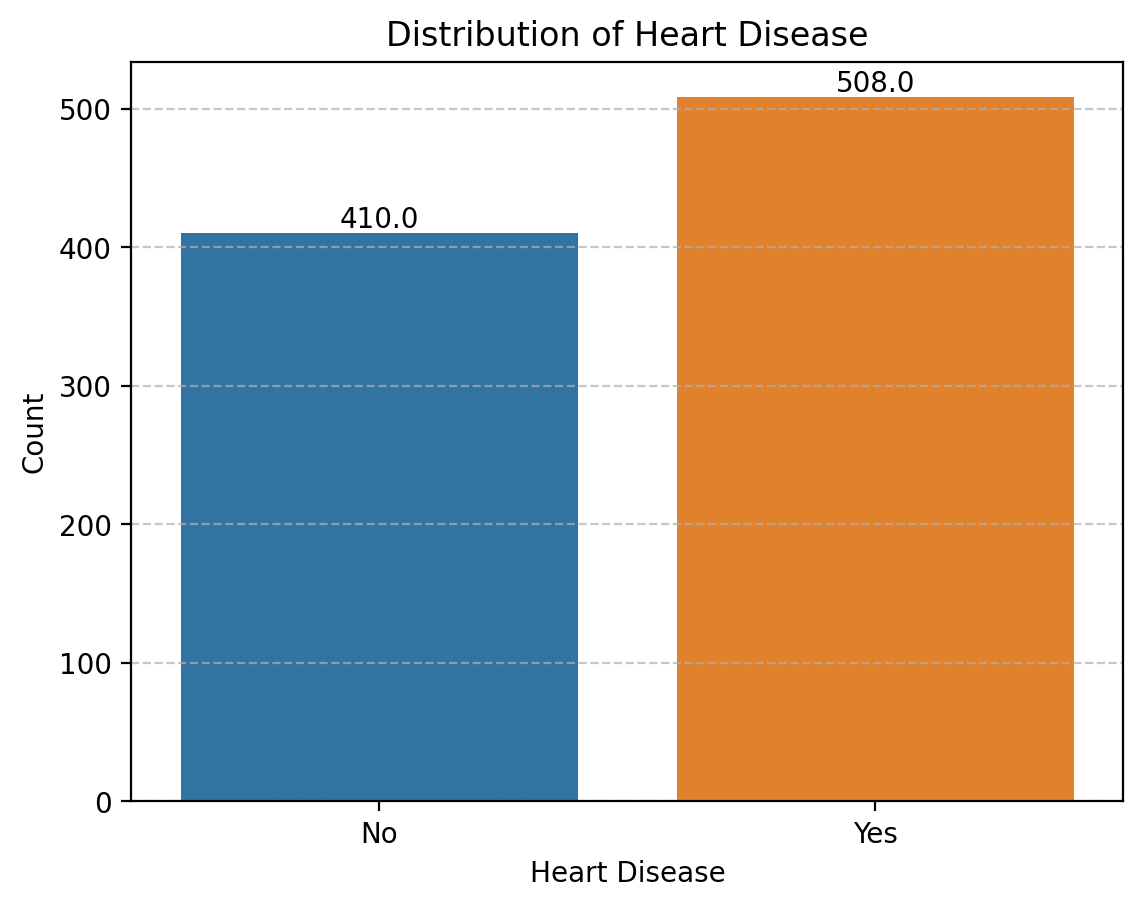

In [560]:
# Create a bar plot of the categories of the `HeartDisease` column
# Add a title and labels to the plot
# Add a horizontal grid to the plot
# Add the count of each category on top of the bars
sns.countplot(x='HeartDisease', data=df, hue='HeartDisease', legend=False)
plt.title('Distribution of Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

#### Age

We calculate the summary statistics of the `Age` column.

In [561]:
# Calculate the summary statistics for the `Age` column
age_summary = df['Age'].describe()
print(age_summary)

count    918.000000
mean      53.510893
std        9.432617
min       28.000000
25%       47.000000
50%       54.000000
75%       60.000000
max       77.000000
Name: Age, dtype: float64


For the $918$ patients, the mean age is $53.5$ years old with a standard deviation of $9.43$. The minimum recorded age is $28$ years old, the $25\%$ mark is $47$ years old, the $50\%$ mark is $54$ years old, the $75\%$ mark is $60$ years old, and the maximum recorded age is $77$ years old.

In [562]:
# Calculate the interquartile range (IQR) for the `Age` column
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1
print(f"IQR for Age: {IQR}")

IQR for Age: 13.0


The interquartile range for the `Age` column is $13$ years.

We calculate the summary statistics of the `Age` column in the two categories of the `HeartDisease` column.

In [563]:
# Calculate the summary statistics of the 'age' column for the two categories of the 'HeartDisease' column
age_heart_disease_summary = df.groupby('HeartDisease')['Age'].describe()
print(age_heart_disease_summary)

              count       mean       std   min   25%   50%   75%   max
HeartDisease                                                          
No            410.0  50.551220  9.444915  28.0  43.0  51.0  57.0  76.0
Yes           508.0  55.899606  8.727056  31.0  51.0  57.0  62.0  77.0


Those with heart disease are, on average, older.

We calculate the interquartile range for each category of the `HeartDisease` column and create a box-and-whisker plot to compare the `Age` column between the two categories of the `Heart Disease` column.

In [564]:
# Use the stats module to calculate the interquartile range (IQR) for each category of the `HeartDisease` column
age_heart_disease_iqr = df.groupby('HeartDisease')['Age'].apply(lambda x: stats.iqr(x))
print(age_heart_disease_iqr)

HeartDisease
No     14.0
Yes    11.0
Name: Age, dtype: float64


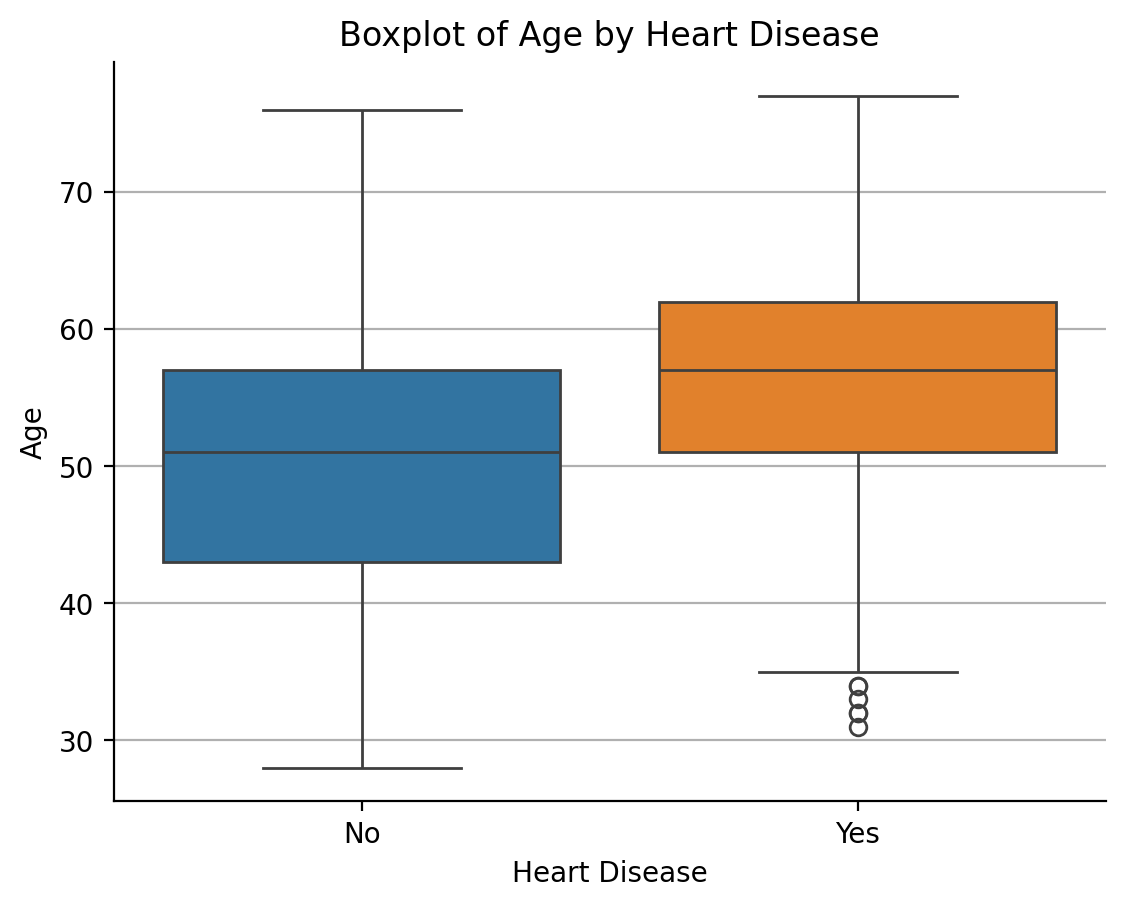

In [565]:
# Create a box-and-whisker plot of the `Age` column for the two categories of the `HeartDisease` column
# Add a title and labels to the plot
# Add a horizontal grid to the plot
# Remove the top and right spines from the plot
sns.boxplot(x='HeartDisease', y='Age', data=df, hue='HeartDisease', legend=False)
plt.title('Boxplot of Age by Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Age')
plt.grid(axis='y')
sns.despine()
plt.show()

The median age is higher for individuals with heart disease compared to those without heart disease. The interquartile range (IQR) is also wider for individuals with heart disease, indicating more variability in age among this group.

We create a histogram of the `Age` for each category in the `HeartDisease` column.

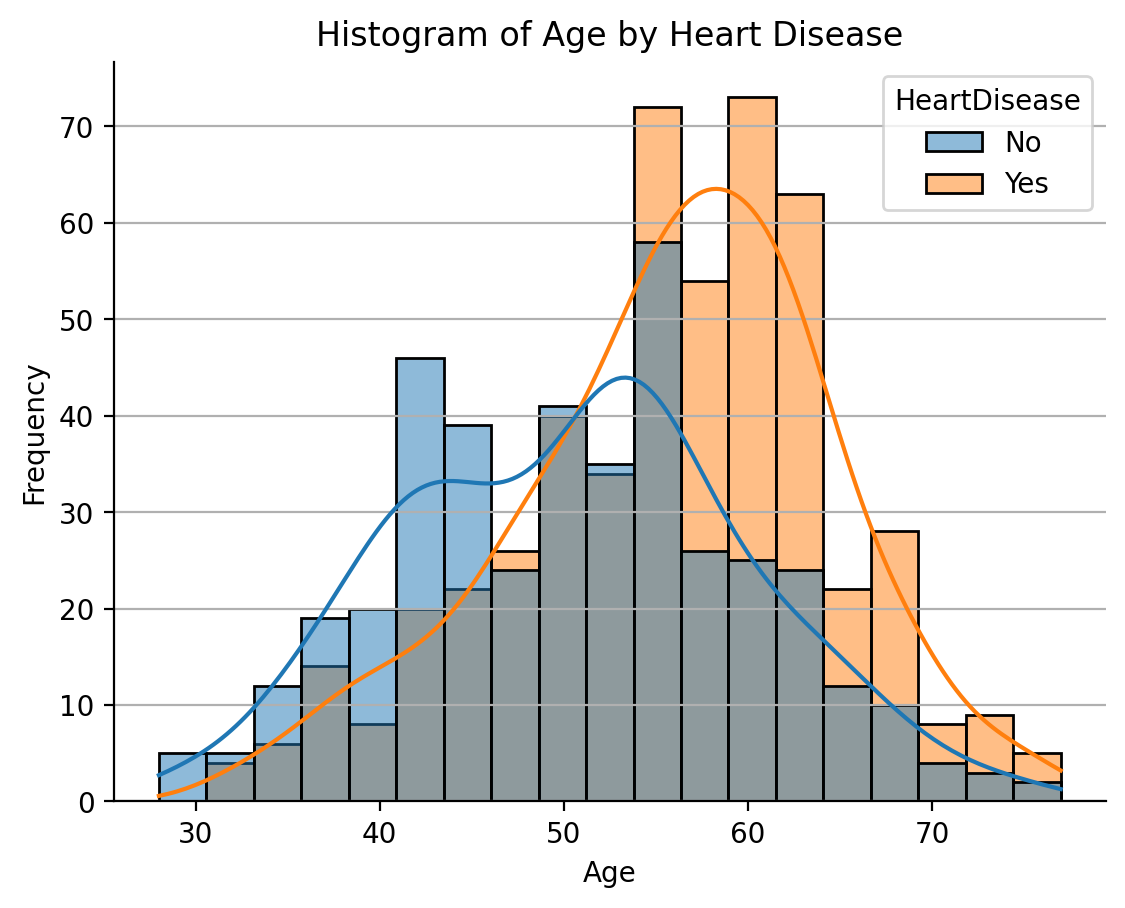

In [566]:
# create a histogram of the `Age` column for the two categories of the `HeartDisease` column
# Add a title and labels to the plot
# Add a vertical grid to the plot
# Remove the top and right spines from the plot
sns.histplot(data=df, x='Age', hue='HeartDisease', kde=True)
plt.title('Histogram of Age by Heart Disease')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y')
sns.despine()
plt.show()

There is a higher presence of heart disease in patients past $55$ years of age.

#### Sex

We find the unique values, frequencies, and percentages of the `Sex` column

In [567]:
# return the unique values in the `Sex` column
df['Sex'].unique()

array(['M', 'F'], dtype=object)

The two categories are $M$ for male and $F$ for female.

In [568]:
# return the frequency of each unique value in the `Sex` column
df['Sex'].value_counts()

Sex
M    725
F    193
Name: count, dtype: int64

There are $725$ male patients and $193$ female patients.

In [569]:
# return the percentage of each unique value in the `Sex` column
df['Sex'].value_counts(normalize=True) * 100

Sex
M    78.976035
F    21.023965
Name: proportion, dtype: float64

Of the $918$ patients, $79.98\%$ of them are male, and $21.02\%$ of them are female.

We create a bar plot to compare the presence of heart disease between male and female patients.

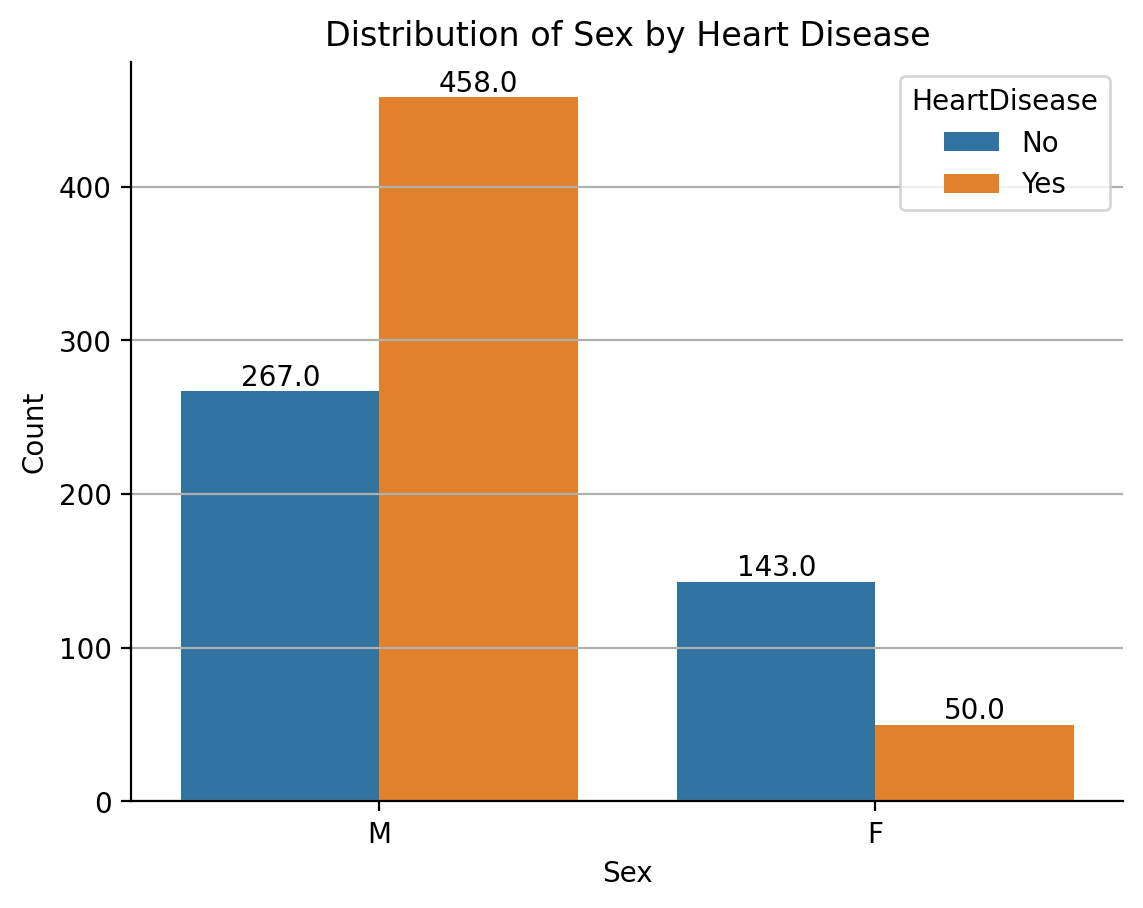

In [570]:
# create a bar plot of the categories of the `Sex` column for the two categories of the `HeartDisease` column
# Add a title and labels to the plot
# Add a horizontal grid to the plot
# Remove the top and right spines from the plot
# add the count of each category on top of the bars
sns.countplot(x='Sex', hue='HeartDisease', data=df)
plt.title('Distribution of Sex by Heart Disease')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.grid(axis='y')
for p in plt.gca().patches:
    if p.get_height() > 0: # Only annotate bars with height > 0
        plt.gca().annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')
sns.despine()
plt.show()

The graph above shows that males have a higher frequency than females to have heart disease.

We find the percent chance of having heart disease depending if you are male or female.

In [571]:
# Calculate the percent chance for males to have heart disease than females
male_heart_disease_percentage = df[df['Sex'] == 'M']['HeartDisease'].value_counts(normalize=True)['Yes'] * 100
print(f"Percent chance for males to have heart disease: {male_heart_disease_percentage:.2f}%")
female_heart_disease_percentage = df[df['Sex'] == 'F']['HeartDisease'].value_counts(normalize=True)['Yes'] * 100
print(f"Percent chance for females to have heart disease: {female_heart_disease_percentage:.2f}%")

# Calculate the increase chance of heart disease for male compared to female
increase_chance = male_heart_disease_percentage - female_heart_disease_percentage
print(f"Increase chance of heart disease for males compared to females: {increase_chance:.2f}%")

Percent chance for males to have heart disease: 63.17%
Percent chance for females to have heart disease: 25.91%
Increase chance of heart disease for males compared to females: 37.27%


While there are more males than females in the dataset, heart disease is more prevalent among males than females.

#### Chest Pain Type

We find the unique values, frequencies, and percentages of the `ChestPainType` column.

In [572]:
# return the unique values in the ChestPainType column
df['ChestPainType'].unique()

array(['ATA', 'NAP', 'ASY', 'TA'], dtype=object)

The values for the `ChestPainType` column are ATA (Atypical Angina), NAP (Non-Angina Pain), ASY (Asymptomatic), and TA (Typical Angina).

In [573]:
# return the frequency of each unique value in the ChestPainType column
df['ChestPainType'].value_counts()

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

There are $496$ with ASY, $203$ with NAP, $173$ with ATA, and $46$ with TA chest pain.

In [574]:
# return the percentage of each unique value in the ChestPainType column
df['ChestPainType'].value_counts(normalize=True) * 100

ChestPainType
ASY    54.030501
NAP    22.113290
ATA    18.845316
TA      5.010893
Name: proportion, dtype: float64

There are $54.03\%$ with ASY, $22.11\%$ with NAP, $18.85\%$ with ATA, and $5.01\%$ with TA chest pain. The most common is Asymptomatic chest pain.

We create a bar plot and heat map with the categories of the `ChestPainType` column for the categories of patients with and without heart disease.

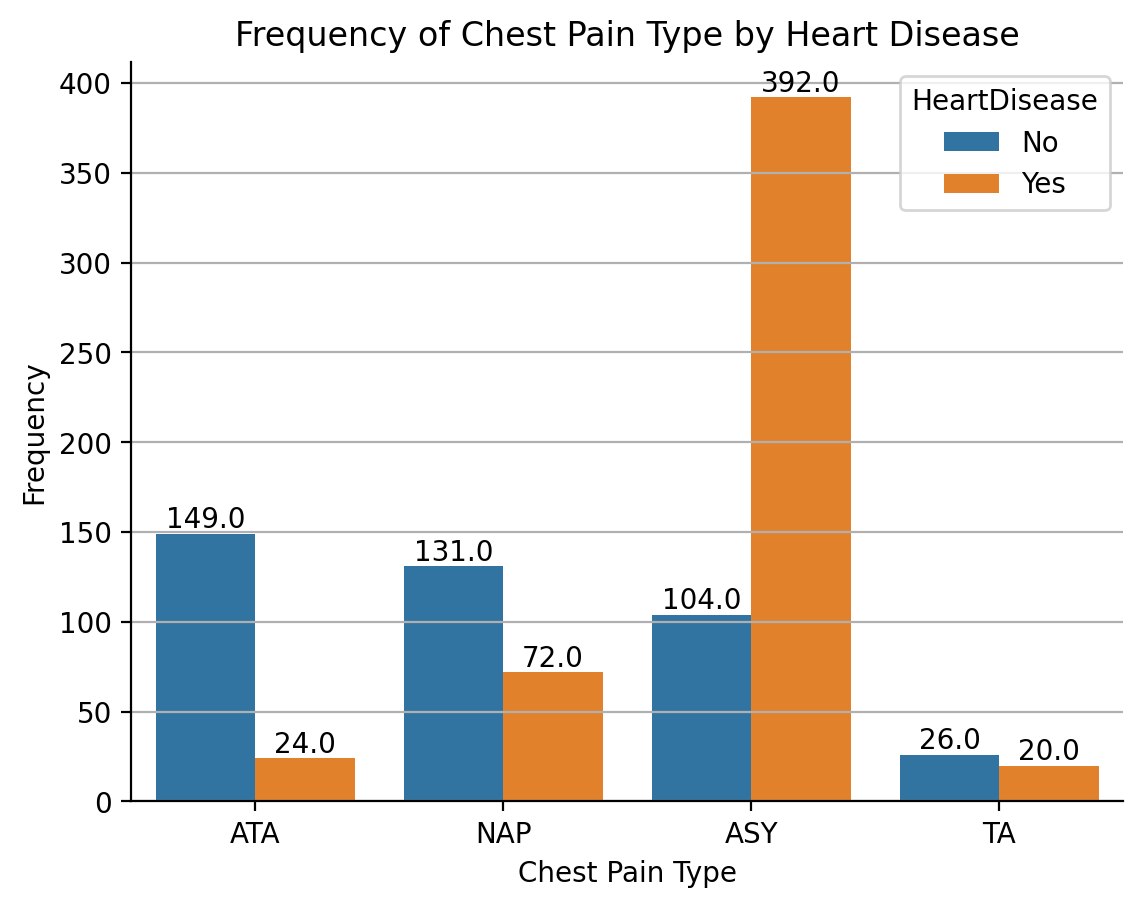

In [575]:
# create a bar plot of the categories of the `ChestPainType` column for the two categories of the `HeartDisease` column
# Add a title and labels to the plot
# Add a horizontal grid to the plot
# Remove the top and right spines from the plot
# add the count of each category on top of the bars
sns.countplot(x='ChestPainType', hue='HeartDisease', data=df)
plt.title('Frequency of Chest Pain Type by Heart Disease')
plt.xlabel('Chest Pain Type')
plt.ylabel('Frequency')
plt.grid(axis='y')
for p in plt.gca().patches:
    if p.get_height() > 0: # Only annotate bars with height > 0
        plt.gca().annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')
sns.despine()
plt.show()

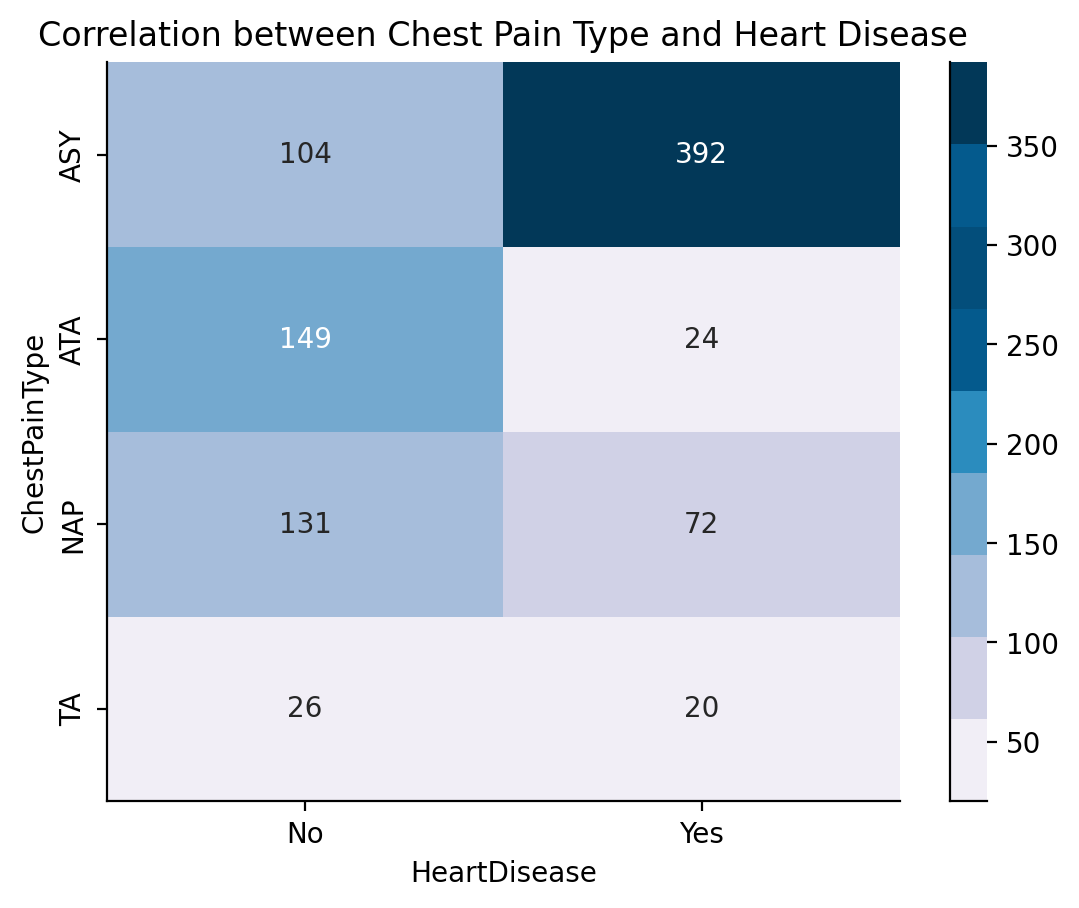

In [576]:
# create a heatmap of the correlation between the categories of the `ChestPainType` column and the categories of the `HeartDisease` column
# Add a title to the plot
# Remove the top and right spines from the plot
# use #f1eef6 #d0d1e6 #a6bddb #74a9cf #2b8cbe #045a8d #034e7b #045a8d #023858 as the colors for the heatmap
chest_pain_heart_disease_crosstab = pd.crosstab(df['ChestPainType'], df['HeartDisease'])
sns.heatmap(chest_pain_heart_disease_crosstab, annot=True, fmt='d', cmap=['#f1eef6', '#d0d1e6', '#a6bddb', '#74a9cf', '#2b8cbe', '#045a8d', '#034e7b', '#045a8d', '#023858'])
plt.title('Correlation between Chest Pain Type and Heart Disease')
sns.despine()
plt.show()

Those with asymptomatic chest pain have a higher frequency of heart disease than those with typical angina, atypical angina, or non-anginal chest pain.

#### Resting Blood Pressure

We calculate the summary statistics of the `RestingBP` column.

In [577]:
# return the summary statistics of the `RestingBP` column
df['RestingBP'].describe()

count    917.000000
mean     132.540894
std       17.999749
min       80.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: RestingBP, dtype: float64

For the $917$ patients, the mean resting blood pressure is around $132.5$ mmHg with a standard deviation of $18.0$mmHg. The minimum resting blood pressure is $80.0$ mmHg, the $25\%$ mark is $120.0$ mmHg, the $50\%$ mark is $130.0$ mmHg, the $75\%$ mark is $140.0$ mmHg, and the maximum recorded resting blood pressure is $200$ mmHg.

In [578]:
# Calculate the interquartile range (IQR) for the `RestingBP` column
Q1 = df['RestingBP'].quantile(0.25)
Q3 = df['RestingBP'].quantile(0.75)
IQR = Q3 - Q1
print(f"IQR for RestingBP: {IQR}")

IQR for RestingBP: 20.0


The interquartile range for the `RestingBP` column is $20.0$.

We calculate the summary statistcs of the `RestingBP` column in the two categories of the `HeartDisease` column.

In [579]:
# Calculate the summary statistics of the `RestingBP` column for the two categories of the `HeartDisease` column
resting_bp_heart_disease_summary = df.groupby('HeartDisease')['RestingBP'].describe()
print(resting_bp_heart_disease_summary)

              count        mean        std   min    25%    50%    75%    max
HeartDisease                                                                
No            410.0  130.180488  16.499585  80.0  120.0  130.0  140.0  190.0
Yes           507.0  134.449704  18.928797  92.0  120.0  132.0  145.0  200.0


While those with heart disease have a slightly higher resting blood pressure, patients with and without heart disease have very close mean and median resting blood pressure.

We calculate the interquartile range and create a box-and-whisker plot of the `RestingBP` column for the two categories of the `HeartDisease` column.

In [580]:
# calculate the interquartile range (IQR) for the `RestingBP` column for the two categories of the `HeartDisease` column
resting_bp_heart_disease_iqr = df.groupby('HeartDisease')['RestingBP'].apply(lambda x: stats.iqr(x)).dropna()
print(resting_bp_heart_disease_iqr)

HeartDisease
No    20.0
Name: RestingBP, dtype: float64


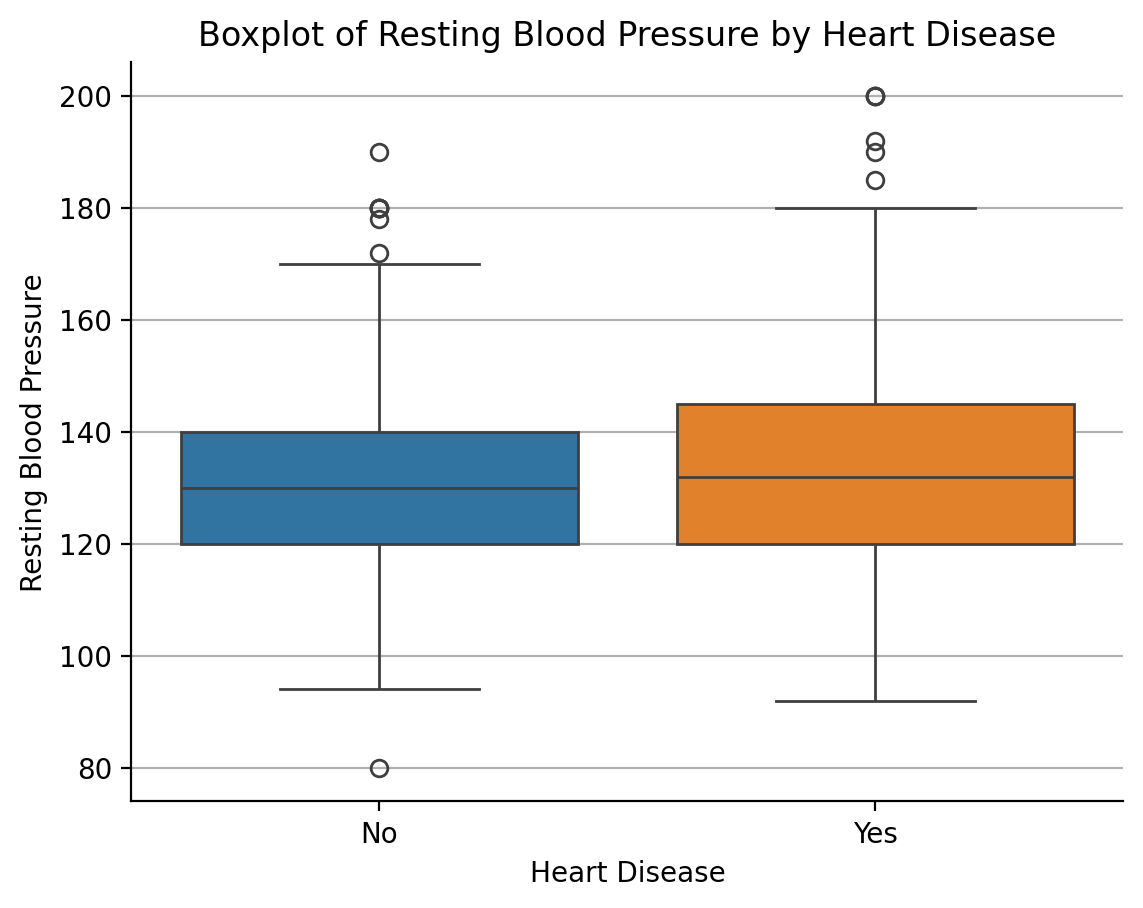

In [581]:
# create a box-and-whisker plot of the `RestingBP` column for the two categories of the `HeartDisease` column
# Add a title and labels to the plot
# Add a horizontal grid to the plot
# Remove the top and right spines from the plot
# use different colors for the two categories of the `HeartDisease` column
sns.boxplot(x='HeartDisease', y='RestingBP', data=df, hue='HeartDisease', legend=False)
plt.title('Boxplot of Resting Blood Pressure by Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Resting Blood Pressure')
plt.grid(axis='y')
sns.despine()
plt.show()

The median of the `RestingBP` column for the two categories of the `HeartDisease` column are similar, with the median for the `No` category being $130$ and the median for the `Yes` category being $132$. This suggests that there may not be a strong relationship between resting blood pressure and heart disease. The IQR range for the `No` category is $20$ and the IQR range for the `Yes` category is $25$, which suggests that there may be more variability in resting blood pressure among individuals with heart disease compared to those without heart disease in this dataset.

We create a histogram of the `RestingBP` for each category in the `HeartDisease` column.

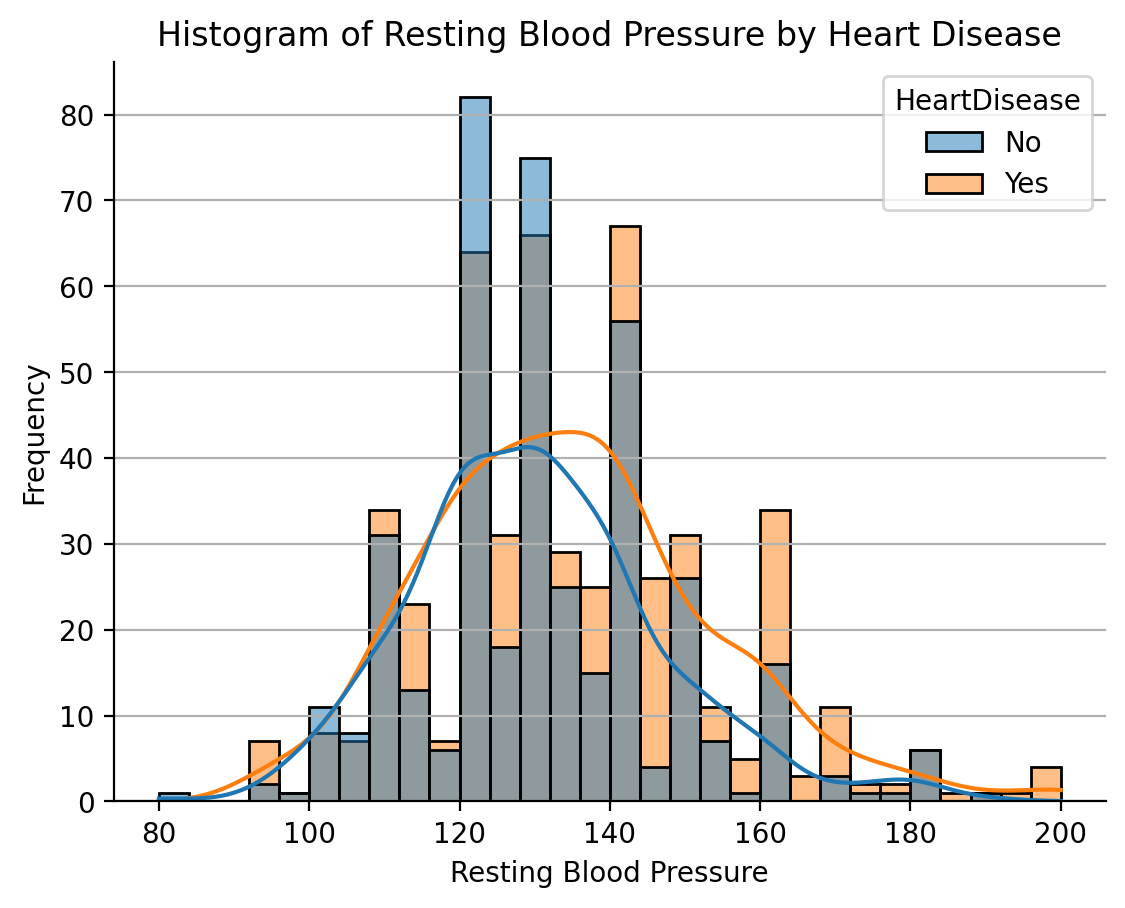

In [582]:
# create a histogram of the `RestingBP` column for the two categories of the `HeartDisease` column
# Add a title and labels to the plot
# Add a vertical grid to the plot
# Remove the top and right spines from the plot
sns.histplot(data=df, x='RestingBP', hue='HeartDisease', kde=True)
plt.title('Histogram of Resting Blood Pressure by Heart Disease')
plt.xlabel('Resting Blood Pressure')
plt.ylabel('Frequency')
plt.grid(axis='y')
sns.despine()
plt.show()

While the two histograms of the `RestingBP` column for the two categories of the `HeartDisease` column look similar, the heart disease group has a slightly higher frequency of higher resting blood pressure values compared to the no heart disease group. This suggests that there may be a relationship between resting blood pressure and heart disease, with higher resting blood pressure potentially being associated with an increased risk of heart disease.

#### Cholesterol

We calculate the summary statistics of the `Cholesterol` column.

In [583]:
# return the summary statistics of the `cholesterol` column
df['Cholesterol'].describe()

count    746.000000
mean     244.635389
std       59.153524
min       85.000000
25%      207.250000
50%      237.000000
75%      275.000000
max      603.000000
Name: Cholesterol, dtype: float64

For the $746$ patients, the mean cholesterol level is $244.64$ mg/dl with a standard deviation of $59.15$ mg/dl. The minimum recorded cholesterol level is $85.0$ mg/dl, the $25\%$ mark is $207.25$ mg/dl, the $50\%$ mark is $237.0$ mg/dl, the $75\%$ mark is $275.0$ mg/dl, and the maximum recorded cholesterol level is $603.0$ mg/dl.

In [584]:
# calculate the interquartile range (IQR) for the `Cholesterol` column
Q1 = df['Cholesterol'].quantile(0.25)
Q3 = df['Cholesterol'].quantile(0.75)
IQR = Q3 - Q1
print(f"IQR for Cholesterol: {IQR}")

IQR for Cholesterol: 67.75


The interquartile range for the `Cholesterol` column is $67.75$ mg/dl.

We calculate the summary statistics of the `Cholesterol` column in the two categories of the `HeartDisease` column.

In [585]:
# return the summary statistics of the `Cholesterol` column for the two categories of the `HeartDisease` column
cholesterol_heart_disease_summary = df.groupby('HeartDisease')['Cholesterol'].describe()
print(cholesterol_heart_disease_summary)

              count        mean        std    min    25%    50%     75%    max
HeartDisease                                                                  
No            390.0  238.769231  55.394617   85.0  203.0  231.5  269.00  564.0
Yes           356.0  251.061798  62.462713  100.0  212.0  246.0  283.25  603.0


People with heart disease have higher average and median cholesterol levels.

We calculate the interquartile range and create a box-and-whisker plot of the `Cholesterol` column for the two categories of the `HeartDisease` column.

In [586]:
# calculate the interquartile range (IQR) for the `Cholesterol` column for the two categories of the `HeartDisease` column
# ignore the rows with NaN values in the `Cholesterol` column for the IQR calculation
cholesterol_heart_disease_iqr = df.groupby('HeartDisease')['Cholesterol'].apply(lambda x: stats.iqr(x.dropna()))
print(cholesterol_heart_disease_iqr)

HeartDisease
No     66.00
Yes    71.25
Name: Cholesterol, dtype: float64


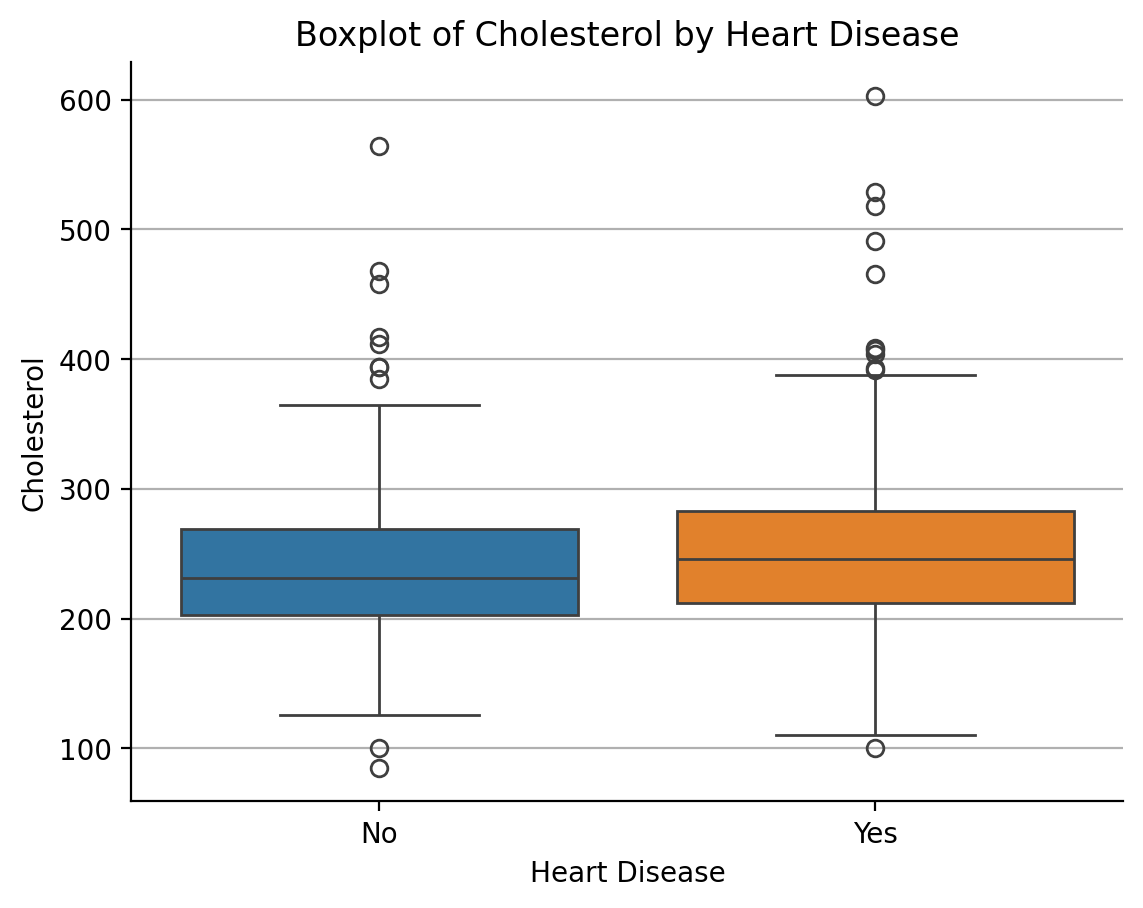

In [587]:
# create a box-and-whisker plot of the `Cholesterol` column for the two categories of the `HeartDisease` column
# Add a title and labels to the plot
# Add a horizontal grid to the plot
# Remove the top and right spines from the plot
# use different colors for the two categories of the `HeartDisease` column
sns.boxplot(x='HeartDisease', y='Cholesterol', data=df, hue='HeartDisease', legend=False)
plt.title('Boxplot of Cholesterol by Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Cholesterol')
plt.grid(axis='y')
sns.despine()
plt.show()

The box-and-whisker plot above shows that the median cholesterol level is higher for people with heart disease than for those without heart disease. The interquartile range (IQR) for cholesterol levels is also wider for people with heart disease, indicating more variability in cholesterol levels among those with heart disease. Additionally, there are some outliers in the cholesterol levels for both groups, but they are more pronounced in the group with heart disease.

We create a histogram of the `Cholesterol` for each category in the `HeartDisease` column.

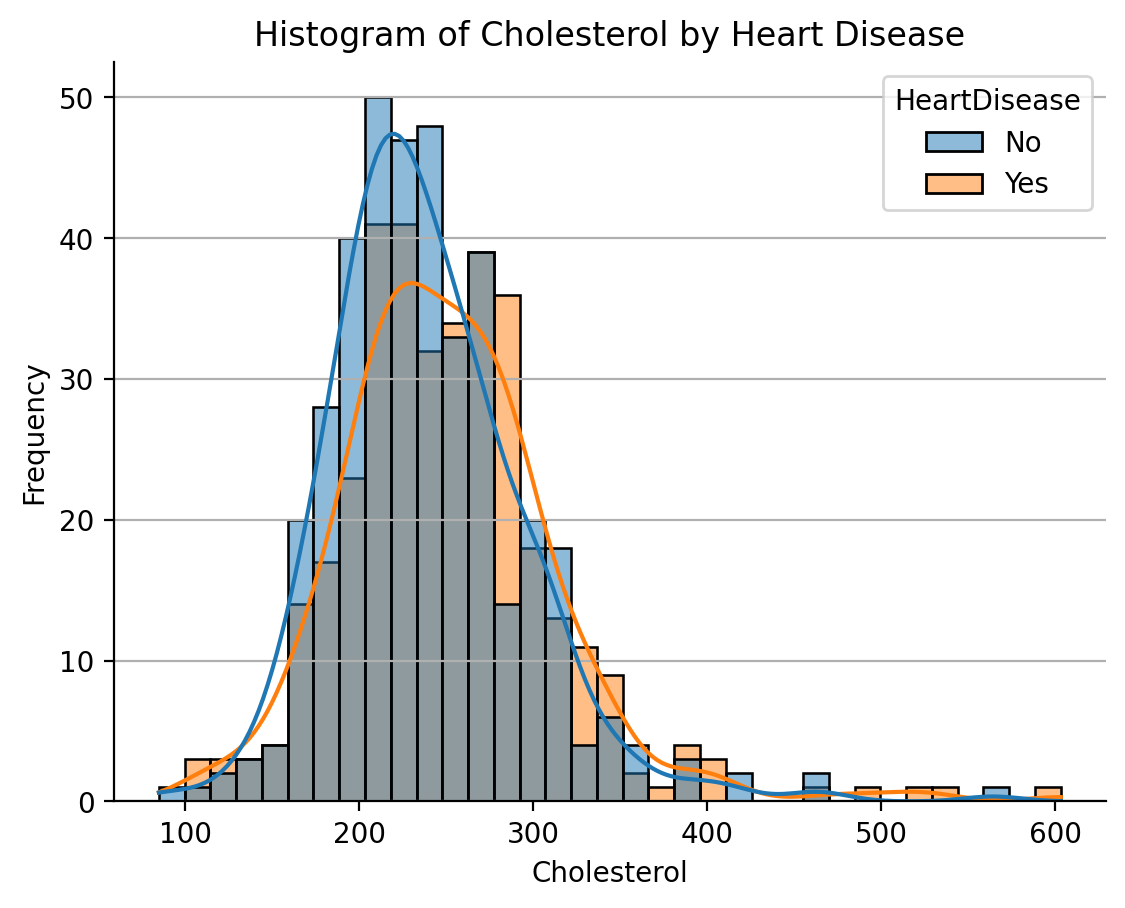

In [588]:
# create a histogram of the `Cholesterol` column for the two categories of the `HeartDisease` column
# Add a title and labels to the plot
# Add a vertical grid to the plot
# Remove the top and right spines from the plot
sns.histplot(data=df, x='Cholesterol', hue='HeartDisease', kde=True)
plt.title('Histogram of Cholesterol by Heart Disease')
plt.xlabel('Cholesterol')
plt.ylabel('Frequency')
plt.grid(axis='y')
sns.despine()
plt.show()

The histogram shows that people with heart disease tend to have slightly higher cholesterol levels compared to those without heart disease.

#### Fasting Blood Sugar

We find the unique values, frequencies, and percentages of the `FastingBS` column.

In [589]:
# return the unique values in the `FastingBS` column
df['FastingBS'].unique()

array(['Normal', 'High'], dtype=object)

The `FastingBS` column records whether a patient's fasting blood sugar is higher than $120$ mg/dl ("High"), or lower ("Normal").

In [590]:
# return the frequency of each unique value in the `FastingBS` column
df['FastingBS'].value_counts()

FastingBS
Normal    704
High      214
Name: count, dtype: int64

$704$ patients have a normal fasting blood sugar below $120$ mg/dl and $214$ patients have a high fasting blood sugar above $120$ mg/dl.

In [591]:
# return the percentage of each unique value in the `FastingBS` column
df['FastingBS'].value_counts(normalize=True) * 100

FastingBS
Normal    76.688453
High      23.311547
Name: proportion, dtype: float64

$76.7\%$ of patients have a normal fasting blood sugar below $120$ mg/dl and $23.3\%$ of patients have a fasting blood sugar above $120$ mg/dl.

We create a bar plot to compare the presence of heart disease between high and normal fasting blood sugar.

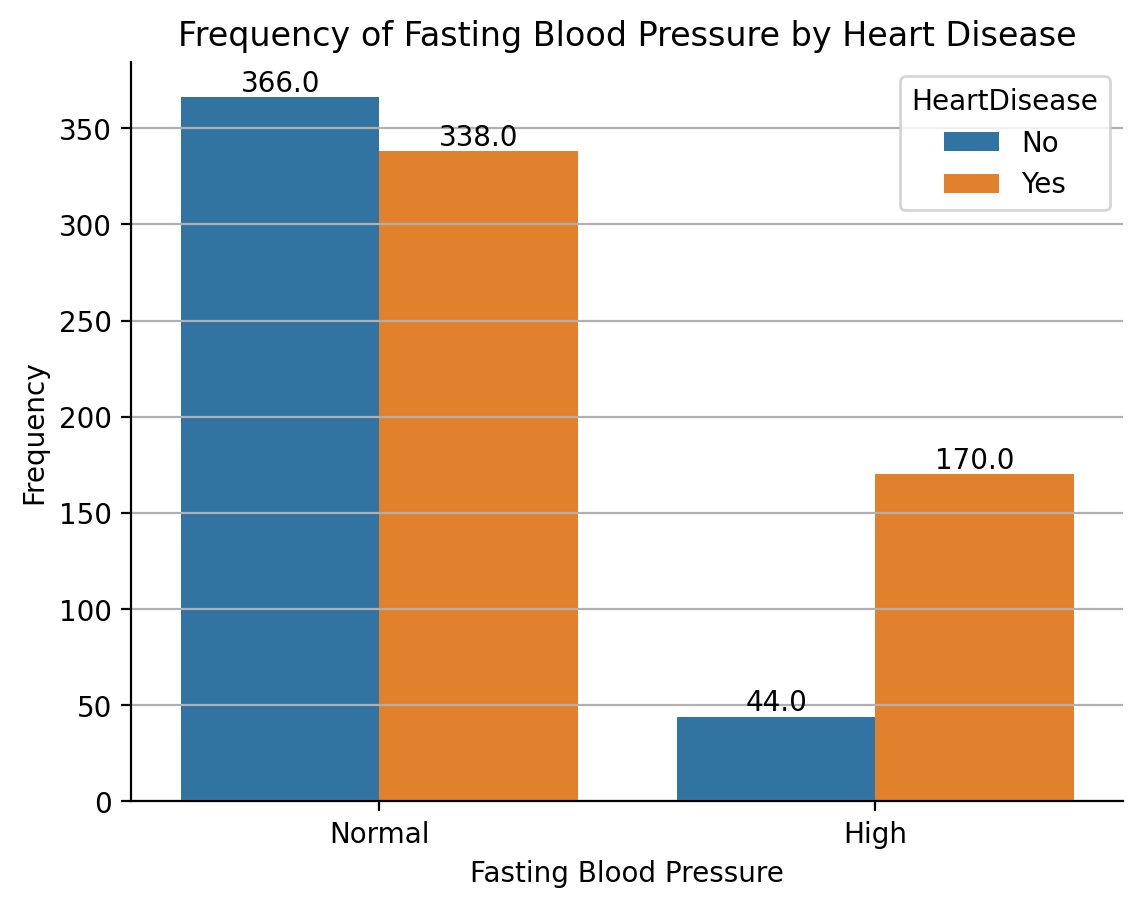

In [592]:
# create a bar plot of the categories of the `FastingBS` column for the two categories of the `HeartDisease` column
# Add a title and labels to the plot
# Add a horizontal grid to the plot
# Remove the top and right spines from the plot
sns.countplot(x='FastingBS', hue='HeartDisease', data=df)
plt.title('Frequency of Fasting Blood Pressure by Heart Disease')
plt.xlabel('Fasting Blood Pressure')
plt.ylabel('Frequency')
plt.grid(axis='y')
for p in plt.gca().patches:
    if p.get_height() > 0: # Only annotate bars with height > 0
        plt.gca().annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')
sns.despine()
plt.show()

The graph above shows that people with high fasting blood sugar have a higher frequency of heart disease than people with normal fasting blood sugar.

We calculate the percent chance of the presence of heart disease depending on high or normal fasting blood pressure.

In [593]:
# calculate the percent chance for people with high fasting blood pressure to have heart disease than people with normal fasting blood pressure
high_fasting_bs_heart_disease_percentage = df[df['FastingBS'] == 'High']['HeartDisease'].value_counts(normalize=True)['Yes'] * 100
print(f"Percent chance for people with high fasting blood pressure to have heart disease: {high_fasting_bs_heart_disease_percentage:.2f}%")
print(f"Percent chance for people with normal fasting blood pressure to have heart disease: {100 - high_fasting_bs_heart_disease_percentage:.2f}%")

Percent chance for people with high fasting blood pressure to have heart disease: 79.44%
Percent chance for people with normal fasting blood pressure to have heart disease: 20.56%


This suggests a higher risk of heart disease for individuals with high fasting blood sugar compared to those with normal fasting blood sugar.

#### Resting ECG

We find the unique values, frequencies, and percentages of the `RestingECG` column.

In [594]:
# return the unique values in the `RestingECG` column
df['RestingECG'].unique()

array(['Normal', 'ST', 'LVH'], dtype=object)

The three categories in the `RestingECG` column is a "normal," "LVH" (Left Ventricular Hypertrophy), and "ST" (ST-T abnormality) resting ECG result.

In [595]:
# return the frequency of each unique value in the `RestingECG` column
df['RestingECG'].value_counts()

RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

Of $918$ patients, $552$ have normal, $188$ have LVH, and $178$ have ST resting ECG results.

In [596]:
# return the percentage of each unique value in the `RestingECG` column
df['RestingECG'].value_counts(normalize=True) * 100

RestingECG
Normal    60.130719
LVH       20.479303
ST        19.389978
Name: proportion, dtype: float64

$60.13\%$ have normal, $20.48\%$ have LVH, and $19.39\%$ have ST resting ECG results.

We create a bar plot of the categories of the `RestingECG` column for the two categories of the `HeartDisease` column.

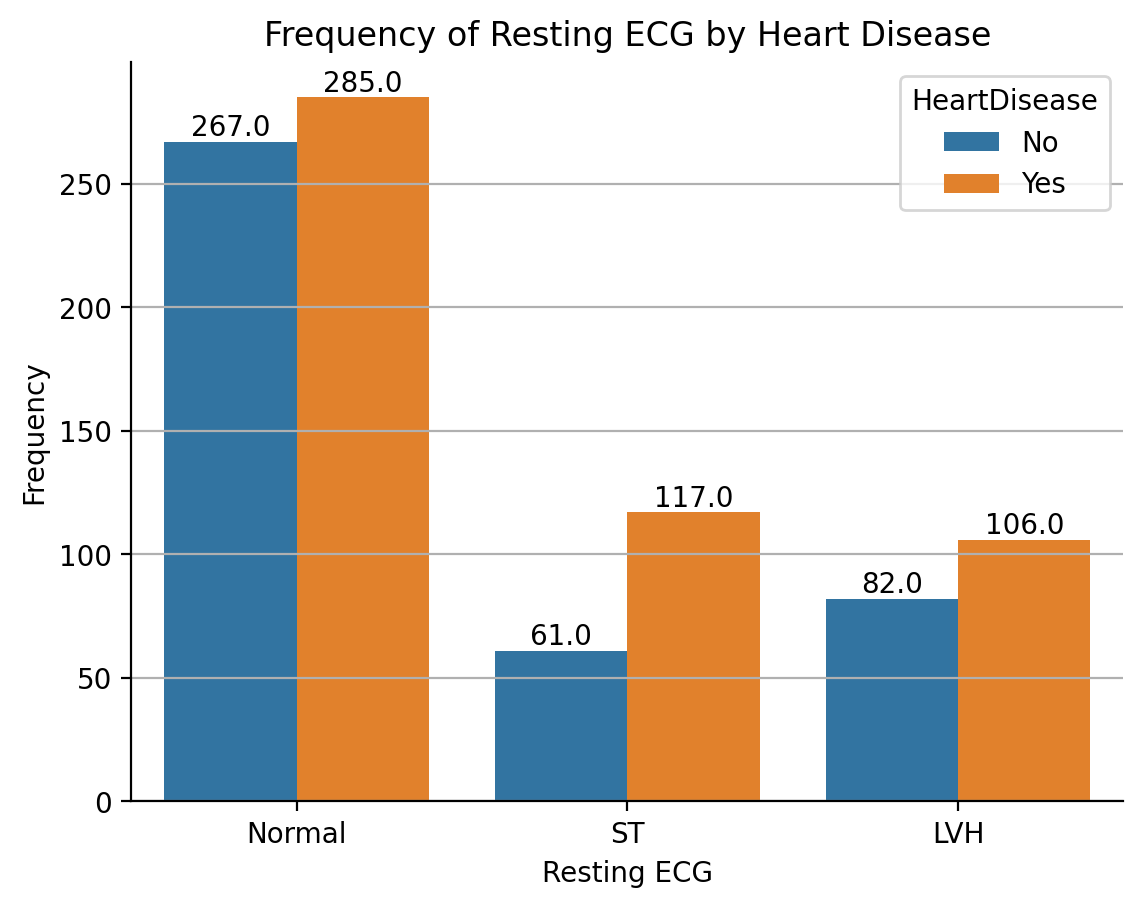

In [597]:
# create a bar plot of the categories of the `RestingECG` column for the two categories of the `HeartDisease` column
# Add a title and labels to the plot
# Add a horizontal grid to the plot
# Remove the top and right spines from the plot
sns.countplot(x='RestingECG', hue='HeartDisease', data=df)
plt.title('Frequency of Resting ECG by Heart Disease')
plt.xlabel('Resting ECG')
plt.ylabel('Frequency')
plt.grid(axis='y')
for p in plt.gca().patches:
    if p.get_height() > 0: # Only annotate bars with height > 0
        plt.gca().annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')
sns.despine()
plt.show()

The barplot shows that there are more people with normal resting ECG, but having ST or LVH does not significantly increase the chance of having heart disease compared to having a normal resting ECG.

#### Max Heart Rate

We calculate the summary statistics of the `MaxHR` column.

In [598]:
# return the summary statistics of the `MaxHR` column
df['MaxHR'].describe()

count    918.000000
mean     136.809368
std       25.460334
min       60.000000
25%      120.000000
50%      138.000000
75%      156.000000
max      202.000000
Name: MaxHR, dtype: float64

For the $918$ patients, the mean max heart rate is $136.8$ bpm with a standard deviation of $25.46$ bpm. The minimum recorded max heart rate is $60.0$ bpm, the $25\%$ mark is $120.0$ bpm, the $50\%$ mark is $138.0$ bpm, the $75\%$ mark is $156.0$ bpm, and the maximum recorded max heart rate is $202.0$ bpm.

In [599]:
# calculate the interquartile range (IQR) for the `MaxHR` column
Q1 = df['MaxHR'].quantile(0.25)
Q3 = df['MaxHR'].quantile(0.75)
IQR = Q3 - Q1
print(f"IQR for MaxHR: {IQR}")

IQR for MaxHR: 36.0


The interquartile range for the `MaxHR` column is $36.0$ bpm.

We calculate the summary statistics of the `MaxHR` column in the two categories of the `HeartDisease` column.

In [600]:
# return the summary statistics of `MaxHR` column for the two categories of the `HeartDisease` column
max_hr_heart_disease_summary = df.groupby('HeartDisease')['MaxHR'].describe()
print(max_hr_heart_disease_summary)

              count        mean        std   min    25%    50%     75%    max
HeartDisease                                                                 
No            410.0  148.151220  23.288067  69.0  134.0  150.0  165.00  202.0
Yes           508.0  127.655512  23.386923  60.0  112.0  126.0  144.25  195.0


Those with heart disease have a lower max heart rate than those without heart disease, which may indicate that they have a lower level of physical fitness.

We calculat the interquartile for each categories of the `HeartDisease` column and create a box-and-whisker plot to compare the `MaxHR` column between the two categories of the `HeartDisease` column.

In [601]:
# calculate the interquartile range (IQR) for the `MaxHR` column for the two categories of the `HeartDisease` column
max_hr_heart_disease_iqr = df.groupby('HeartDisease')['MaxHR'].apply(lambda x: stats.iqr(x))
print(max_hr_heart_disease_iqr)

HeartDisease
No     31.00
Yes    32.25
Name: MaxHR, dtype: float64


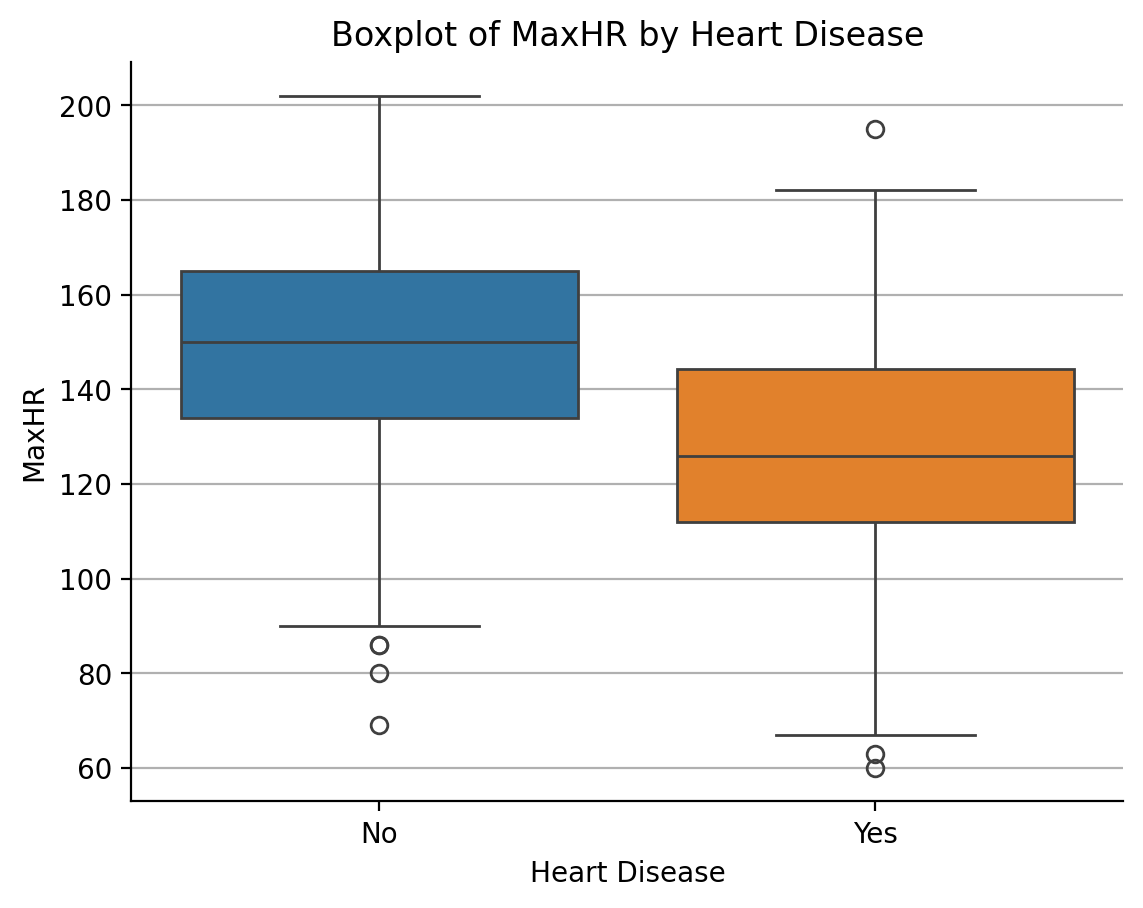

In [602]:
# create a box-and-whisker plot of the `MaxHR` column for the two categories of the `HeartDisease` column
# Add a title and labels to the plot
# Add a horizontal grid to the plot
# Remove the top and right spines from the plot
# use different colors for the two categories of the `HeartDisease` column
sns.boxplot(x='HeartDisease', y='MaxHR', data=df, hue='HeartDisease', legend=False)
plt.title('Boxplot of MaxHR by Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('MaxHR')
plt.grid(axis='y')
sns.despine()
plt.show()

The box-and-whisker plot above shows that the median MaxHR for people with heart disease is lower than the median MaxHR for people without heart disease. The interquartile range (IQR) for people with heart disease is also smaller than the IQR for people without heart disease, indicating that there is less variability in MaxHR among people with heart disease.

We create a histogram of the `MaxHR` column for theache category in the `HeartDisease` column.

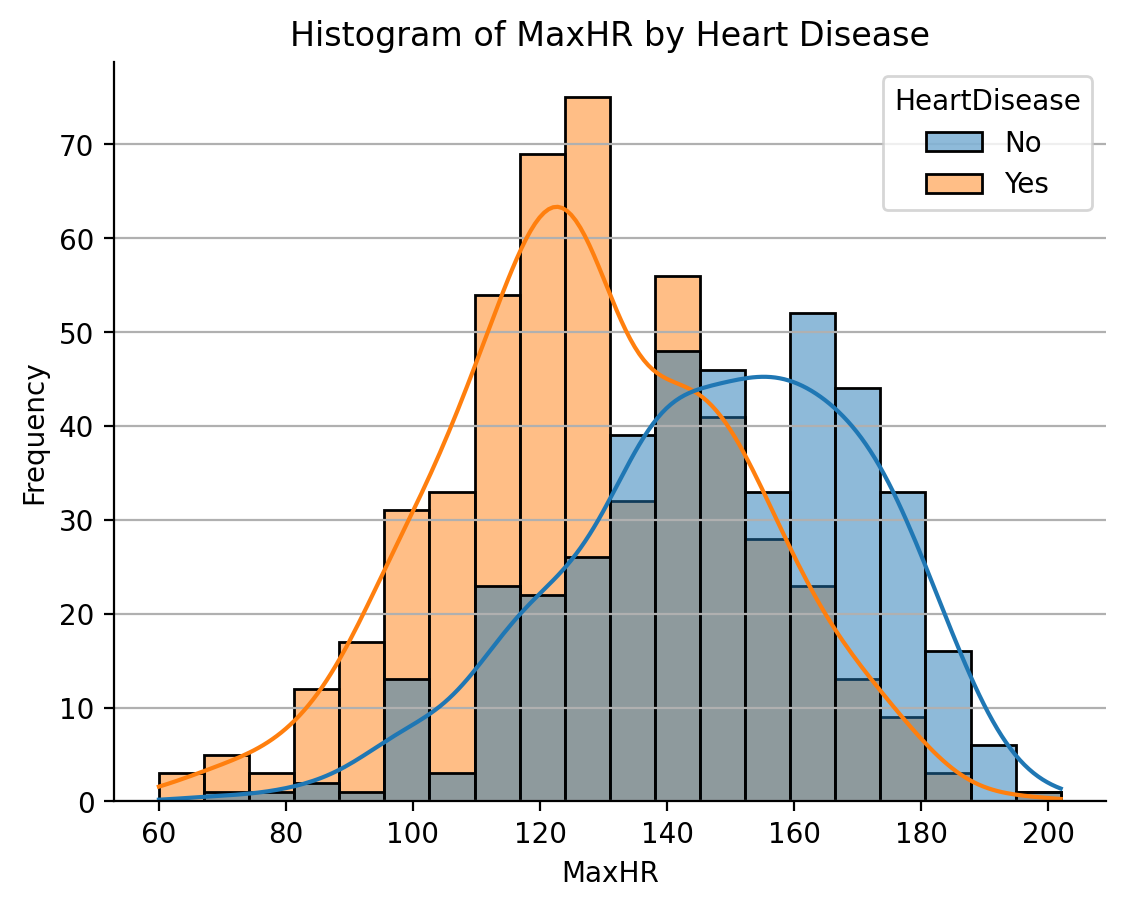

In [603]:
# create a histogram of the `MaxHR` column for the two categories of the `HeartDisease` column
# Add a title and labels to the plot
# Add a vertical grid to the plot
# Remove the top and right spines from the plot
sns.histplot(data=df, x='MaxHR', hue='HeartDisease', kde=True)
plt.title('Histogram of MaxHR by Heart Disease')
plt.xlabel('MaxHR')
plt.ylabel('Frequency')
plt.grid(axis='y')
sns.despine()
plt.show()

The histogram above shows that heart disease is more prevalent in people with lower max heart rates than people with higher max heart rates.

We calculate the percent chance of presence of heart disease between people with higher and lower max heart rates.

In [604]:
# calculate the percent chance for people with higher maximum heart rate to have heart disease than people with lower maximum heart rate
high_max_hr_heart_disease_percentage = df[df['MaxHR'] > df['MaxHR'].median()]['HeartDisease'].value_counts(normalize=True)['Yes'] * 100
print(f"Percent chance for people with higher maximum heart rate to have heart disease: {high_max_hr_heart_disease_percentage:.2f}%")
print(f"Percent chance for people with lower maximum heart rate to have heart disease: {100 - high_max_hr_heart_disease_percentage:.2f}%")

Percent chance for people with higher maximum heart rate to have heart disease: 38.41%
Percent chance for people with lower maximum heart rate to have heart disease: 61.59%


There is a higher chane of having heart disease for people with lower maximum heart rate than people with higher maximum heart rate.

#### Exercise Angina

We find the unique values, frequencies, and percentages of the `ExerciseAngina` column.

In [605]:
# return the unique values in the `ExerciseAngina` column
df['ExerciseAngina'].unique()

array(['No', 'Yes'], dtype=object)

The two categories of the `ExerciseAngina` column are "Yes," they have exercise-induced angina, and "No," they do not have exercise-induced angina.

In [606]:
# return the frequency of each unique value in the `ExerciseAngina` column
df['ExerciseAngina'].value_counts()

ExerciseAngina
No     547
Yes    371
Name: count, dtype: int64

Of $918$ patients, $547$ do not have exercise-induced angina, and $371$ have exercise-induced angina.

In [607]:
# return the percentage of each unique value in the `ExerciseAngina` column
df['ExerciseAngina'].value_counts(normalize=True) * 100

ExerciseAngina
No     59.586057
Yes    40.413943
Name: proportion, dtype: float64

$59.59\%$ of patients do not have exercise-induced angina, and $40.41\%$ have exercise-induced angina.

We create a bar plot and heat map to compare the presence of heart disease in people with and without exercise-induced angina.

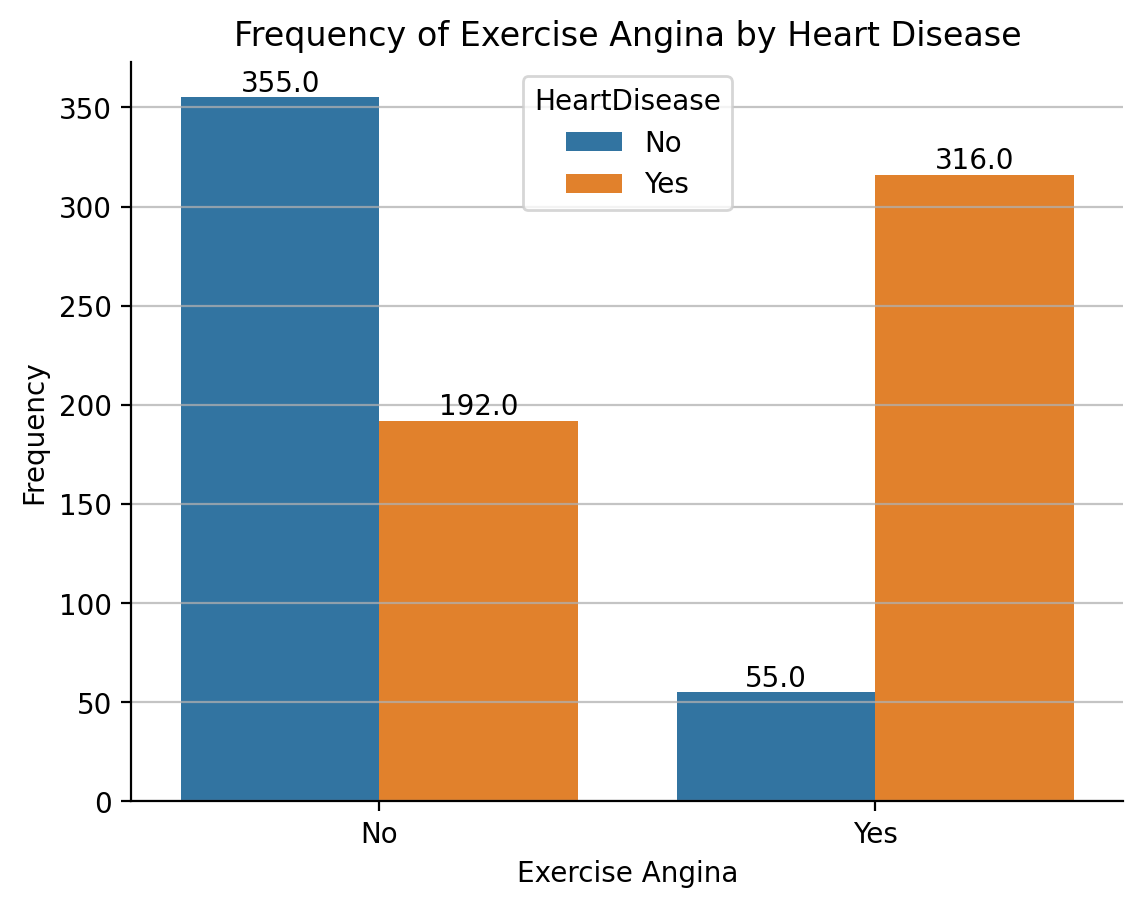

In [608]:
# create a bar plot of the categories of the `ExerciseAngina` column for the two categories of the `HeartDisease` column
# Add a title and labels to the plot
# Add a horizontal grid to the plot
# Remove the top and right spines from the plot
sns.countplot(x='ExerciseAngina', hue='HeartDisease', data=df)
plt.title('Frequency of Exercise Angina by Heart Disease')
plt.xlabel('Exercise Angina')   
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
for p in plt.gca().patches:
    if p.get_height() > 0: # Only annotate bars with height > 0
        plt.gca().annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

The bar plot shows that people with exercise-induced angina are more likely to have heart disease than people without exercise-induced angina.

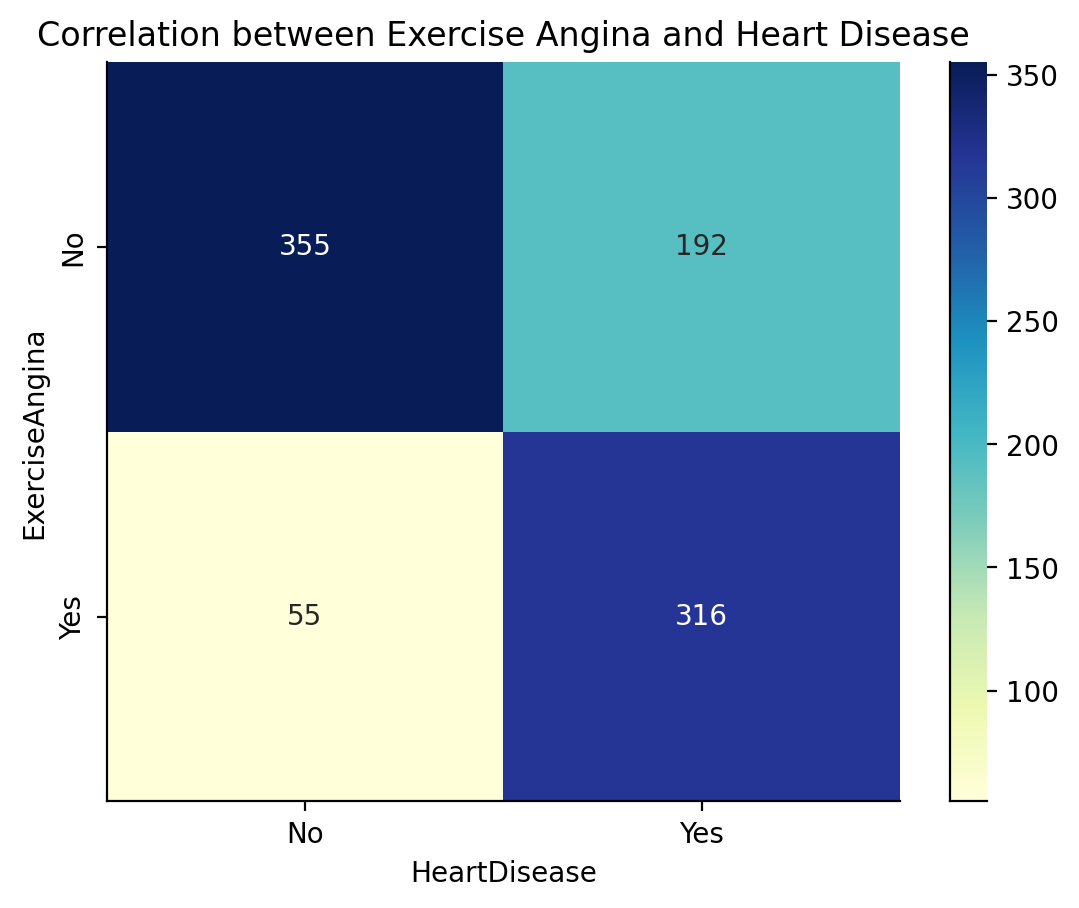

In [609]:
# create a heat map of the correlation between the categories of the `ExerciseAngina` column and the categories of the `HeartDisease` column
exercise_angina_heart_disease_crosstab = pd.crosstab(df['ExerciseAngina'], df['HeartDisease'])
sns.heatmap(exercise_angina_heart_disease_crosstab, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Correlation between Exercise Angina and Heart Disease')
sns.despine()
plt.show()

The heatmap above shows that there is a strong correlation between exercise angina and heart disease, with a higher frequency of heart disease among those with exercise angina compared to those without exercise angina.

We calculate the percent chance of the presence of heart disease between people with and without exercise-induced angina.

In [610]:
# calculate the increase in the percent chance of having heart disease for those with exercise angina compared to those without exercise angina
exercise_angina_heart_disease_crosstab = pd.crosstab(df['ExerciseAngina'], df['HeartDisease'])
exercise_angina_yes_heart_disease_yes = exercise_angina_heart_disease_crosstab.loc['Yes', 'Yes']
exercise_angina_yes_heart_disease_no = exercise_angina_heart_disease_crosstab.loc['Yes', 'No']
exercise_angina_no_heart_disease_yes = exercise_angina_heart_disease_crosstab.loc['No', 'Yes']
exercise_angina_no_heart_disease_no = exercise_angina_heart_disease_crosstab.loc['No', 'No']
percent_chance_exercise_angina_yes = exercise_angina_yes_heart_disease_yes / (exercise_angina_yes_heart_disease_yes + exercise_angina_yes_heart_disease_no) * 100
percent_chance_exercise_angina_no = exercise_angina_no_heart_disease_yes / (exercise_angina_no_heart_disease_yes + exercise_angina_no_heart_disease_no) * 100
percent_increase = percent_chance_exercise_angina_yes - percent_chance_exercise_angina_no
print(f"Percent chance of having heart disease for those with exercise angina: {percent_chance_exercise_angina_yes:.2f}%")
print(f"Percent chance of having heart disease for those without exercise angina: {percent_chance_exercise_angina_no:.2f}%")
print(f"Percent increase in chance of having heart disease for those with exercise angina compared to those without exercise angina: {percent_increase:.2f}%")

Percent chance of having heart disease for those with exercise angina: 85.18%
Percent chance of having heart disease for those without exercise angina: 35.10%
Percent increase in chance of having heart disease for those with exercise angina compared to those without exercise angina: 50.07%


Exercise-induced angina increases the percent chance of having heart disease by around $50\%$ compared to those without exercise angina.

#### Old Peak

We calculate the sumary statistics of the `Oldpeak` column.

In [611]:
# return the summary statistics of the `oldpeak` column
df['Oldpeak'].describe()

count    918.000000
mean       0.887364
std        1.066570
min       -2.600000
25%        0.000000
50%        0.600000
75%        1.500000
max        6.200000
Name: Oldpeak, dtype: float64

For the $918$ patients, the mean oldpeak is $0.888$ mm with a standard deviation of $1.07$ mm. The minimum recorded oldpeak is $-2.6$ mm, the $25\%$ mark is $0.0$ mm, the $50\%$ mark is $0.6$ mm, the $75\%$ mark is $1.5$ mm, and the maximum recorded olepeak is $6.2$ bpm.

In [612]:
# calculate the interquartile range (IQR) for the `oldpeak` column
Q1 = df['Oldpeak'].quantile(0.25)
Q3 = df['Oldpeak'].quantile(0.75)
IQR = Q3 - Q1
print(f"IQR for Oldpeak: {IQR}")

IQR for Oldpeak: 1.5


The interquartile range for the `Oldpeak` column is $1.5$ mm.

We calculate the summary statistics of the `Oldpeak` column in the two categories of the `HeartDisease` column.

In [613]:
# return the summary statistics of the `oldpeak` column for the two categories of the `HeartDisease` column
oldpeak_heart_disease_summary = df.groupby('HeartDisease')['Oldpeak'].describe()
print(oldpeak_heart_disease_summary)

              count      mean       std  min  25%  50%  75%  max
HeartDisease                                                    
No            410.0  0.408049  0.699709 -1.1  0.0  0.0  0.6  4.2
Yes           508.0  1.274213  1.151872 -2.6  0.0  1.2  2.0  6.2


The mean and average oldpeak is higher in the population with heart disease than the population without heart disease.

We calculate the interquartile range (IQR) for each category of the `HeartDisease` column and create a box-and-whisker plot of the `Oldpeak` column for the two categories of the `HeartDisease` column.

In [614]:
# calculate the interquartile range (IQR) for the `oldpeak` column for the two categories of the `HeartDisease` column
oldpeak_heart_disease_iqr = df.groupby('HeartDisease')['Oldpeak'].apply(lambda x: stats.iqr(x))
print(oldpeak_heart_disease_iqr)

HeartDisease
No     0.6
Yes    2.0
Name: Oldpeak, dtype: float64


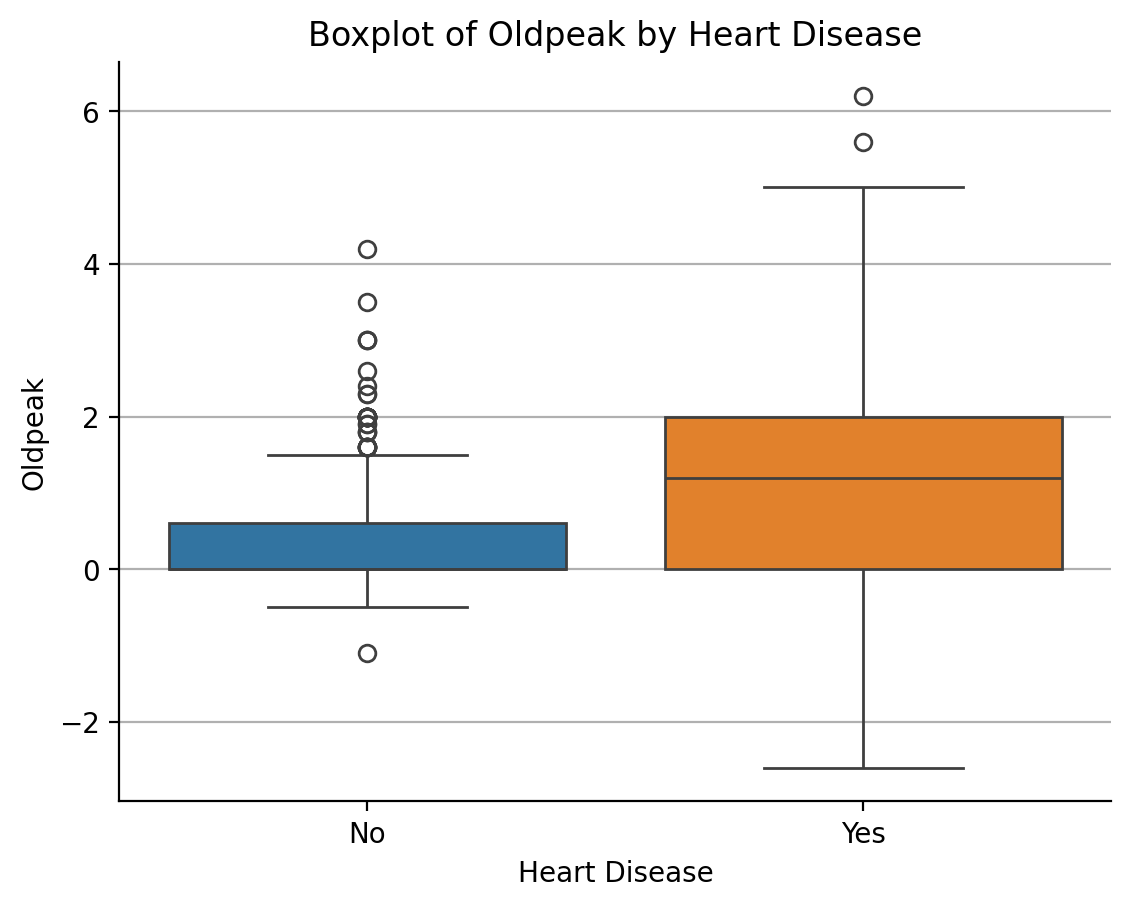

In [615]:
# create a box-and-whisker plot of the `oldpeak` column for the two categories of the `HeartDisease` column
# Add a title and labels to the plot
# Add a horizontal grid to the plot
# Remove the top and right spines from the plot
# use different colors for the two categories of the `HeartDisease` column
sns.boxplot(x='HeartDisease', y='Oldpeak', data=df, hue='HeartDisease', legend=False)
plt.title('Boxplot of Oldpeak by Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Oldpeak')
plt.grid(axis='y')
sns.despine()
plt.show()

The box-and-whisker plot above shows that the oldpeak values for those with heart disease are generally higher than those without heart disease. The interquartile range (IQR) for those with heart disease is larger than the IQR for those without heart disease,so there is more variability in oldpeak values among those with heart disease.

We create a histogram of the `Oldpeak` column for each category in the `HeartDisease` column.

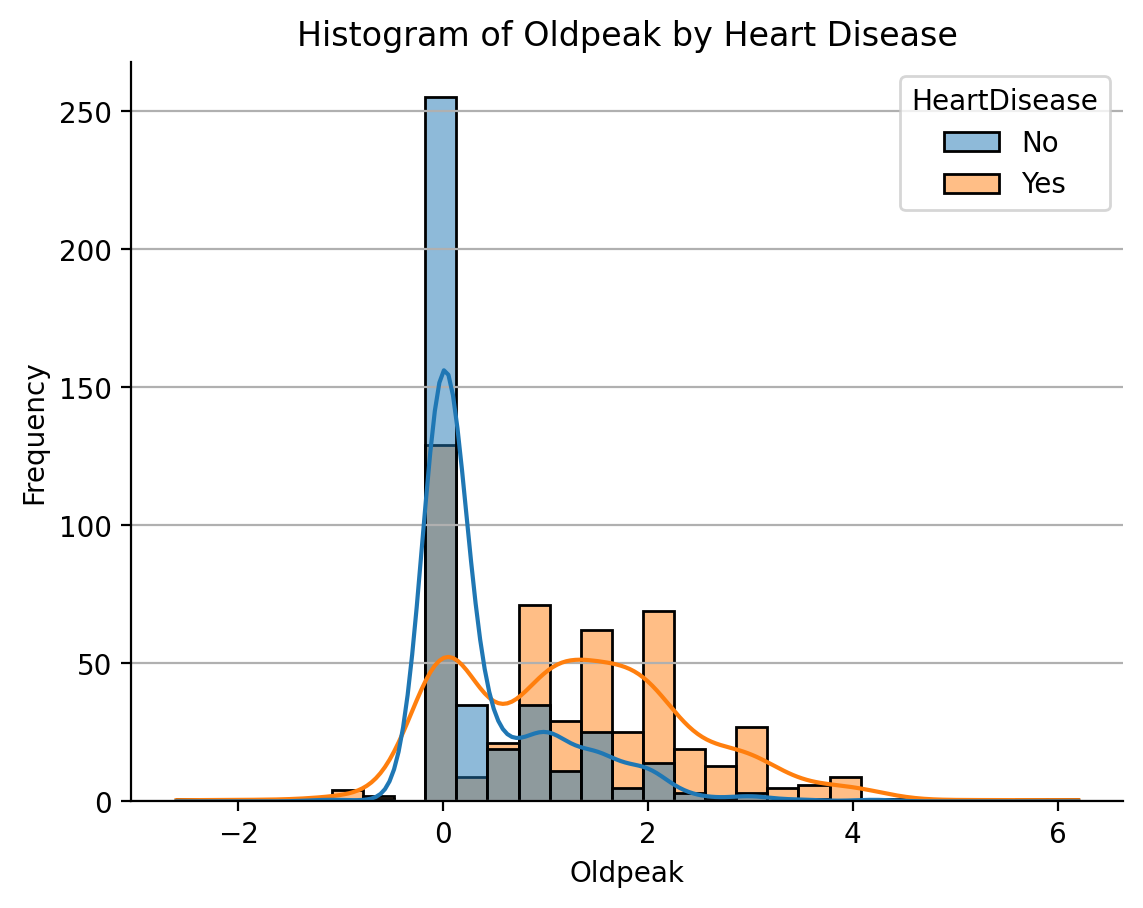

In [616]:
# create a histogram of the `oldpeak` column for the two categories of the `HeartDisease` column
# Add a title and labels to the plot
# Add a vertical grid to the plot
# Remove the top and right spines from the plot
sns.histplot(data=df, x='Oldpeak', hue='HeartDisease', kde=True)
plt.title('Histogram of Oldpeak by Heart Disease')
plt.xlabel('Oldpeak')
plt.ylabel('Frequency')
plt.grid(axis='y')
sns.despine()
plt.show()

The histogram above shows that those with heart disease tend to have higher values of `Oldpeak`, which indicates that they experience more ST depression during exercise. This suggests that there may be a relationship between `Oldpeak` and heart disease, where higher values of `Oldpeak` are associated with an increased likelihood of having heart disease.

We calculate the percent chance of presence of Heart Disease depending on the oldpeak value.

In [617]:
# calculate the percent chance for people with higher oldpeak to have heart disease than people with lower oldpeak
high_oldpeak_heart_disease_percentage = df[df['Oldpeak'] > df['Oldpeak'].median()]['HeartDisease'].value_counts(normalize=True)['Yes'] * 100
print(f"Percent chance for people with higher oldpeak to have heart disease: {high_oldpeak_heart_disease_percentage:.2f}%")
print(f"Percent chance for people with lower oldpeak to have heart disease: {100 - high_oldpeak_heart_disease_percentage:.2f}%")

Percent chance for people with higher oldpeak to have heart disease: 77.35%
Percent chance for people with lower oldpeak to have heart disease: 22.65%


This suggests that people with higher oldpeak are more likely to have heart disease than people with lower oldpeak.

#### ST Slope

We find the unique values, frequencies, and percentages of the `ST_Slope` column.

In [618]:
# return the unique values in the `ST_Slope` column
df['ST_Slope'].unique()

array(['Up', 'Flat', 'Down'], dtype=object)

The three categories for the `ST_Slope` column of the slope of the peak exercise ST segment are "Up" (a postive slope), "Flat" (a slope of $0$), and "Down" (a negative slope).

In [619]:
# return the frequency of each unique value in the `ST_Slope` column
df['ST_Slope'].value_counts()

ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64

Of the $918$ patients, $460$ have a "Flat", $395$ have an "Up", and $63$ have a "Down" sloping ST segnment.

In [620]:
# return the percentage of each unique value in the `ST_Slope` column
df['ST_Slope'].value_counts(normalize=True) * 100

ST_Slope
Flat    50.108932
Up      43.028322
Down     6.862745
Name: proportion, dtype: float64

$50.11\%$ of patients have a "Flat," $43.03\%$ of patients have an "Up," and $6.86\%$ of patients have a "Down" sloping ST segment.

We create a bar plot of the categories of the `FastingBS` column for the two categories in the `HeartDisease` column.

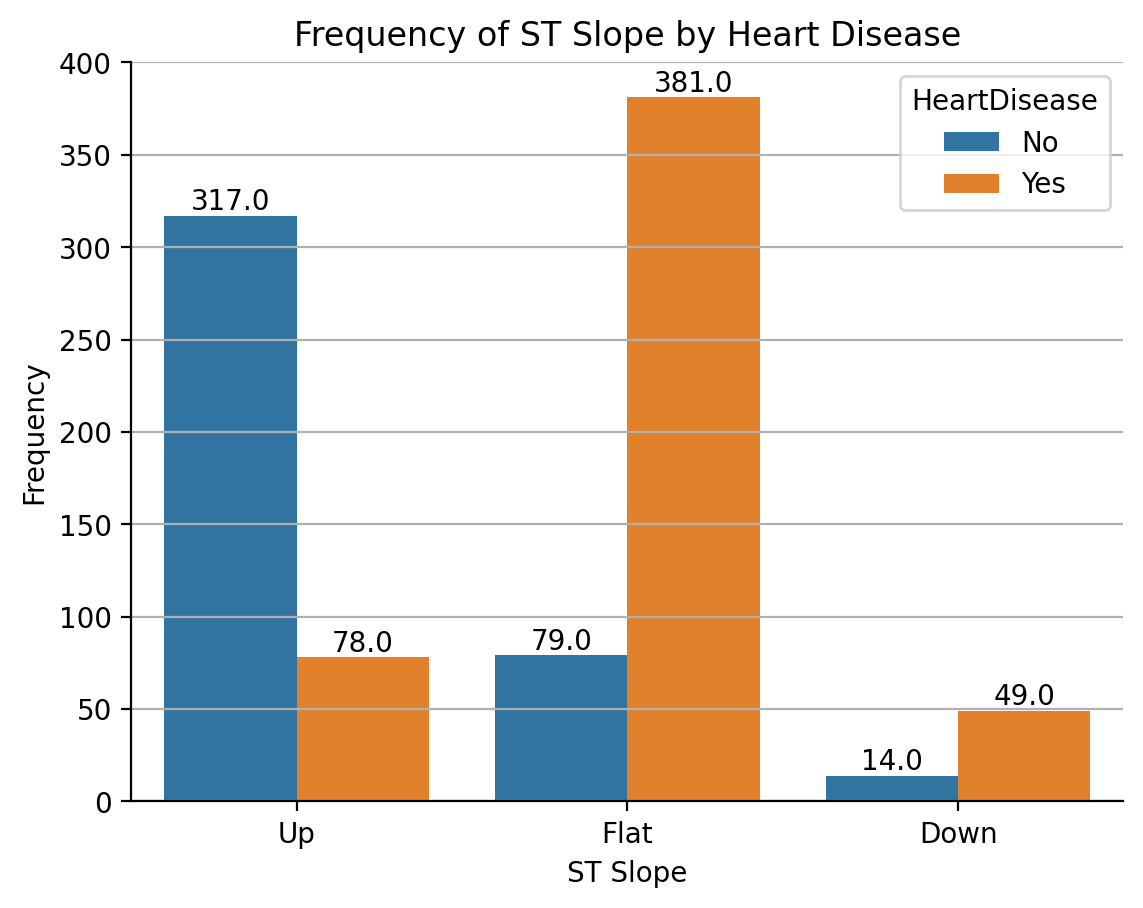

In [621]:
# create a bar plot of the categories of the `ChestPainType` column for the two categories of the `HeartDisease` column
# Add a title and labels to the plot
# Add a horizontal grid to the plot
# Remove the top and right spines from the plot
sns.countplot(x='ST_Slope', hue='HeartDisease', data=df)
plt.title('Frequency of ST Slope by Heart Disease')
plt.xlabel('ST Slope')
plt.ylabel('Frequency')
plt.grid(axis='y')
for p in plt.gca().patches:
    if p.get_height() > 0: # Only annotate bars with height > 0
        plt.gca().annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')
sns.despine()
plt.show()

The barplot above shows that people with a flat and down ST slope have a higher frequency of heart disease than people with an upsloping ST slope.

We calculate the percent chance for people with upsloping ST slope to have heart disease than people with flat or downsloping ST slope.

In [622]:
# calculate the percent chance for people with upsloping ST slope to have heart disease than people with flat or downsloping ST slope
upsloping_st_slope_heart_disease_percentage = df[df['ST_Slope'] == 'Up']['HeartDisease'].value_counts(normalize=True)['Yes'] * 100
print(f"Percent chance for people with upsloping ST slope to have heart disease: {upsloping_st_slope_heart_disease_percentage:.2f}%")
print(f"Percent chance for people with flat or downsloping ST slope to have heart disease: {100 - upsloping_st_slope_heart_disease_percentage:.2f}%")

Percent chance for people with upsloping ST slope to have heart disease: 19.75%
Percent chance for people with flat or downsloping ST slope to have heart disease: 80.25%


People with flat and down sloping ST slope have a higher chance of having heart disease than people with upsloping ST slope.

### Research Questions

#### Difference in Age Between Those with Heart Disease and without Heart Disease.

- $H_{0}$: There is no difference in age between the populations with heart disease and without heart disease.
- $H_{a}$: There is a difference in age between the populations with heart disease and without heart disease.

Do a Shapiro-Wilk test to check for normality of the age distribution in both groups.

In [623]:
# conduct a Shapiro-Wilk test on the 'Age' column for the two categories of the 'HeartDisease' column
heart_disease_no_age = df[df['HeartDisease'] == 'No']['Age']
shapiro_test_result = stats.shapiro(heart_disease_no_age)
print(f"Shapiro-Wilk test statistic for Heart Disease No: {shapiro_test_result.statistic}")  
print(f"Shapiro-Wilk test p-value for Heart Disease No: {shapiro_test_result.pvalue}")
heart_disease_yes_age = df[df['HeartDisease'] == 'Yes']['Age']
shapiro_test_result = stats.shapiro(heart_disease_yes_age)
print(f"Shapiro-Wilk test statistic for Heart Disease Yes: {shapiro_test_result.statistic}")  
print(f"Shapiro-Wilk test p-value for Heart Disease Yes: {shapiro_test_result.pvalue}")

Shapiro-Wilk test statistic for Heart Disease No: 0.9928644800217199
Shapiro-Wilk test p-value for Heart Disease No: 0.04834843555077678
Shapiro-Wilk test statistic for Heart Disease Yes: 0.9851362527999584
Shapiro-Wilk test p-value for Heart Disease Yes: 4.6913219231306e-05


According to the Shapiro-Wilk test results, the p-value for the "No" and "Yes" category of the `HeartDisease` column is less than $0.05$, which indicates that the distribution of ages in this category is not normally distributed. We use a Mann-Whitney U-test to compare the mean age between people with and without heart disease.

In [624]:
# conduct a mann-whitney u test on the 'Age' column for the two categories of the 'HeartDisease' column
u_test_result = stats.mannwhitneyu(heart_disease_no_age, heart_disease_yes_age, alternative='two-sided')
print(f"Mann-Whitney U test statistic for Age: {u_test_result.statistic}")
print(f"Mann-Whitney U test p-value for Age: {u_test_result.pvalue}")

Mann-Whitney U test statistic for Age: 69137.5
Mann-Whitney U test p-value for Age: 1.8056941390292456e-18


There is enough evidence in the data at the $5\%$ level of significance to show that there is a difference in the median age between the populations with and without heart disease. The median age of those with heart disease is $6$ years more than those without heart disease. We reject the null hypothesis.

#### Association Between Sex and Heart Disease

- $H_{0}$: There is no association between sex and heart disease.
- $H_{a}$: There is an association between sex and heart disease.

Create a contingency table between the categories of the `Sex` and `HeartDisease` columns of df.

In [625]:
# create a contingency table of the `Sex` column and the `HeartDisease` columns of df
contingency_table = pd.crosstab(df['Sex'], df['HeartDisease'])
print(contingency_table)

HeartDisease   No  Yes
Sex                   
F             143   50
M             267  458



| Contingency Table | No Heart Disease | Heart Disease |
| :--- | ---: | ---: |
| Female | 143 | 50 |
| Male | 458 | 267 |


There are $143$ females without heart disease and $50$ with heart disease, and $458$ males without heart disease and $267$ with heart disease.

Perform a chi-squared test to find the expected values of patients if there were no association and find the p-value between the `HeartDisease` and `Sex` columns.

In [626]:
# conduct a chi-squared test for association between the `Sex` column and the `HeartDisease` column
# return the chi-squared test statistic, p-value, degrees of freedom, and expected values
ct = contingency_table
chi2, p, dof, expected = stats.chi2_contingency(ct.values, correction=False)
expected_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns)

print('\nChi-squared statistic:', chi2)
print('p-value:', p)
print('degrees of freedom:', dof)
print('\nExpected values:')
print(expected_df)


Chi-squared statistic: 85.64627575933622
p-value: 2.1518038618271832e-20
degrees of freedom: 1

Expected values:
HeartDisease          No         Yes
Sex                                 
F              86.198257  106.801743
M             323.801743  401.198257


There is enough evidence in the data at the $5\%$ level of significance to show that there is an association between sex and heart disease. We reject the null hypothesis.

In [627]:
# calculate the odds ratio of heart disease in males compared to females
odds_ratio = (contingency_table.loc['M', 'Yes'] / contingency_table.loc['M', 'No']) / (contingency_table.loc['F', 'Yes'] / contingency_table.loc['F', 'No'])
odds_ratio

np.float64(4.905917602996255)

The odds ratio of heart disease in males compared to females is approximately $4.91$, which means that males are about $4.91$ times more likely to have heart disease than females.

#### Association Between Chest Pain Type and Heart Disease

- $H_{0}$: There is no association between chest pain type and heart disease.
- $H_{a}$: There is an association between chest pain type and heart disease.

Create a contingency table between the categories of the `ChestPainType` and `HeartDisease` columns of df.

In [628]:
# create a contingency table of the `ChestPainType` column and the `HeartDisease` columns of df
contingency_table = pd.crosstab(df['ChestPainType'], df['HeartDisease'])
print(contingency_table)

HeartDisease    No  Yes
ChestPainType          
ASY            104  392
ATA            149   24
NAP            131   72
TA              26   20



| Contingency Table | No Heart Disease | Heart Disease |
| :--- | ---: | ---: |
| ASY Chest Pain | 104 | 392 |
| ATA Chest Pain | 149 | 24 |
| NAP Chest Pain | 131 | 72 |
| TA Chest Pain | 26 | 20 |

There are $104$ people with ASY chest pain without heart disease and $392$ with heart disease. There are $149$ people with ATA chest pain without heart disease and $24$ with heart disease. There are $131$ people with NAP chest pain without heart disease and $72$ with heart disease. There are $26$ people with TA chest pain without heart disease and $20$ with heart disease.

Perform a chi-squared test to find the expected values of patients if there were no association and find the p-value between the `HeartDisease` and `ChestPainType` columns.

In [629]:
# conduct a chi-squared test for association between the `ChestPainType` column and the `HeartDisease` column
# return the chi-squared test statistic, p-value, degrees of freedom, and expected values
ct = contingency_table
chi2, p, dof, expected = stats.chi2_contingency(ct.values, correction=False)
expected_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns)

print('\nChi-squared statistic:', chi2)
print('p-value:', p)
print('degrees of freedom:', dof)
print('\nExpected values:')
print(expected_df)


Chi-squared statistic: 268.06723902181767
p-value: 8.083728428087649e-58
degrees of freedom: 3

Expected values:
HeartDisease           No         Yes
ChestPainType                        
ASY            221.525054  274.474946
ATA             77.265795   95.734205
NAP             90.664488  112.335512
TA              20.544662   25.455338


There is enough evidence in the data at the $5\%$ level of significance to show that there is an association between chest pain type and heart disease. We reject the null hypthesis.

In [630]:
# calculate the odds ratio for heart disease for each chest pain type compare to other chest pain types
odds_ratios = {}
for chest_pain_type in contingency_table.index:
    odds_ratio = (contingency_table.loc[chest_pain_type, 'Yes'] / contingency_table.loc[chest_pain_type, 'No']) / ((contingency_table['Yes'].sum() - contingency_table.loc[chest_pain_type, 'Yes']) / (contingency_table['No'].sum() - contingency_table.loc[chest_pain_type, 'No']))
    odds_ratios[chest_pain_type] = odds_ratio
odds_ratios

{'ASY': np.float64(9.942970822281167),
 'ATA': np.float64(0.08686005879416495),
 'NAP': np.float64(0.3517053014917011),
 'TA': np.float64(0.6052963430012611)}

The odds ratio of heart disease in people with ASY compared to other chest pain types is approximately $9.94$, which means that people with ASY chest pain type are about $9.94$ times more likely to have heart disease than other chest pain types.

#### Difference in Resting Blood Pressure Between Those with Heart Disease and without Heart Disease

- $H_{0}$: There is no difference in resting blood pressure between the populations with heart disease and without heart disease.
- $H_{a}$: There is a difference in resting blood pressure between the populations with heart disease and without heart disease.

We replace the NaN values of the `RestingBP` columns with the median value.

In [631]:
# replace the NaN values in the `RestingBP` column with the median value of the `RestingBP` column
df['RestingBP'] = df['RestingBP'].fillna(df['RestingBP'].median())

Do a Shapiro-Wilk test to check for normality of the resting blood pressure distribution in both groups.

In [632]:
# Conduct a shapiro-wilk test on the `RestingBP` column for the two categories of the `HeartDisease` column
heart_disease_no_resting_bp = df[df['HeartDisease'] == 'No']['RestingBP']
shapiro_test_result = stats.shapiro(heart_disease_no_resting_bp)
print(f"Shapiro-Wilk test statistic for Heart Disease No: {shapiro_test_result[0]}")
print(f"Shapiro-Wilk test p-value for Heart Disease No: {shapiro_test_result[1]}")
heart_disease_yes_resting_bp = df[df['HeartDisease'] == 'Yes']['RestingBP']
shapiro_test_result = stats.shapiro(heart_disease_yes_resting_bp)
print(f"Shapiro-Wilk test statistic for Heart Disease Yes: {shapiro_test_result[0]}")
print(f"Shapiro-Wilk test p-value for Heart Disease Yes: {shapiro_test_result[1]}")

Shapiro-Wilk test statistic for Heart Disease No: 0.966562602700561
Shapiro-Wilk test p-value for Heart Disease No: 4.6326238527472474e-08
Shapiro-Wilk test statistic for Heart Disease Yes: 0.9744447192512216
Shapiro-Wilk test p-value for Heart Disease Yes: 9.460189054009998e-08


According to the Shapiro-Wilk test results, the p-value for the "No" and "Yes" category of the `HeartDisease` column is less than $0.05$, which indicates that the distribution of resting blood pressures in this category is not normally distributed. We use Mann-Whitney U-test to compare the mean resting blood pressure between people with and without heart disease.

In [633]:
# conduct a Mann-Whitney U-test to compare the mean resting bp for the two categories of the 'HeartDisease' column
u_test_result = stats.mannwhitneyu(heart_disease_no_resting_bp, heart_disease_yes_resting_bp, alternative='two-sided')
print(f"Mann-Whitney U test statistic for RestingBP: {u_test_result.statistic}")
print(f"Mann-Whitney U test p-value for RestingBP: {u_test_result.pvalue}")

Mann-Whitney U test statistic for RestingBP: 90206.0
Mann-Whitney U test p-value for RestingBP: 0.00046203483599121896


There is enough evidence in the data at the $5\%$ level of significance to show that there is a difference in the median resting blood pressure between the populations with and without heart disease. The median resting blood pressure of those with heart disease is $2$ mmHg higher than those without heart disease. We reject the null hypothesis.

#### Difference in Cholesterol Levels Between Those with Heart Disease and without Heart Disease

- $H_{0}$: There is no difference in cholesterol levels between the populations with heart disease and without heart disease.
- $H_{a}$: There is a difference in cholesterol levels between the populations with heart disease and without heart disease.

Do a Shapiro-Wilk test to check for normality of the cholesterol level distribution in both groups, but ignoring values with NaN to avoid them from affecting the test.

In [634]:
# conduct a shapiro-wilk test on the `Cholesterol` column for the two categories of the `HeartDisease` column
# ignore the rows with NaN values in the `Cholesterol` column for the shapiro-wilk test
heart_disease_no_cholesterol = df[df['HeartDisease'] == 'No']['Cholesterol'].dropna()
shapiro_test_result = stats.shapiro(heart_disease_no_cholesterol)
print(f"Shapiro-Wilk test statistic for Heart Disease No: {shapiro_test_result[0]}")
print(f"Shapiro-Wilk test p-value for Heart Disease No: {shapiro_test_result[1]}")
heart_disease_yes_cholesterol = df[df['HeartDisease'] == 'Yes']['Cholesterol'].dropna()
shapiro_test_result = stats.shapiro(heart_disease_yes_cholesterol)
print(f"Shapiro-Wilk test statistic for Heart Disease Yes: {shapiro_test_result[0]}")
print(f"Shapiro-Wilk test p-value for Heart Disease Yes: {shapiro_test_result[1]}")

Shapiro-Wilk test statistic for Heart Disease No: 0.942141664698438
Shapiro-Wilk test p-value for Heart Disease No: 3.4007805836912897e-11
Shapiro-Wilk test statistic for Heart Disease Yes: 0.9305684018408776
Shapiro-Wilk test p-value for Heart Disease Yes: 8.147537335827402e-12


According to the Shapiro-Wilk test results, the p-value for the "No" and "Yes" category of the `HeartDisease` column is less than $0.05$, which indicates that the distribution of cholesterol levels in this category is not normally distributed. We use a Mann-Whitney U-test to compare the mean cholesterol levels between people with and without heart disease.

In [635]:
# conduct a Mann-Whitney U-test to compare the mean cholesterol for the two categories of the 'HeartDisease' column
u_test_result = stats.mannwhitneyu(heart_disease_no_cholesterol, heart_disease_yes_cholesterol, alternative='two-sided')
print(f"Mann-Whitney U test statistic for Cholesterol: {u_test_result.statistic}")
print(f"Mann-Whitney U test p-value for Cholesterol: {u_test_result.pvalue}")

Mann-Whitney U test statistic for Cholesterol: 60200.5
Mann-Whitney U test p-value for Cholesterol: 0.0017130070426659356


There is enough evidence in the data at the $5\%$ level of significance to show that there is a difference in the median cholesterol level between the populations with and without heart disease. The median cholesterol level of those with heart disease is $15$ mg/dl higher than those without heart disease. We reject the null hypothesis.

#### Associaion Between Fasting Blood Sugar and Heart Disease

- $H_{0}$: There is no association between fasting blood sugar and heart disease.
- $H_{a}$: There is an association between fasting blood sugar and heart disease.

Create a contingency table between the categories of the `FastingBS` and `HeartDisease` columns of df.

In [636]:
# create a contingency table of the `FastingBS` column and the `HeartDisease` columns of df
contingency_table = pd.crosstab(df['FastingBS'], df['HeartDisease'])
print(contingency_table)

HeartDisease   No  Yes
FastingBS             
High           44  170
Normal        366  338


| Contingency Table | No Heart Disease | Heart Disease |
| :--- | ---: | ---: |
| High Fasting Blood Sugar | 44 | 170 |
| Normal Fasting Blood Sugar | 366 | 338 |

There are $44$ people with high fasting blood sugar without heart disease and $170$ with heart disease, and $366$ people with normal fasting blood sugar without heart disease and $338$ with heart disease.

Perform a chi-squared test to find the expected values of patients if there were no association and find the p-value between the `HeartDisease` and `FastingBS` columns.

In [637]:
# conduct a chi-squared test for association between the `FastingBS` column and the `HeartDisease` column
# return the test statistic, p-value, and the table of expected values
ct = contingency_table
chi2, p, dof, expected = stats.chi2_contingency(ct.values, correction=False)
expected_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns)

print('\nChi-squared statistic:', chi2)
print('p-value:', p)
print('degrees of freedom:', dof)
print('\nExpected values:')
print(expected_df)


Chi-squared statistic: 65.5861227621255
p-value: 5.562909292372398e-16
degrees of freedom: 1

Expected values:
HeartDisease          No         Yes
FastingBS                           
High           95.577342  118.422658
Normal        314.422658  389.577342


There is enough evidence in the data at the $5\%$ level of significance to show that there is an association between fasting blood sugar and heart disease. We reject the null hypothesis.

In [638]:
# calculate the odds ratio of heart disease for people with high fasting blood pressure compared to people with normal fasting blood pressure
odds_ratio = (contingency_table.loc['High', 'Yes'] / contingency_table.loc['High', 'No']) / (contingency_table.loc['Normal', 'Yes'] / contingency_table.loc['Normal', 'No'])
print(f"Odds ratio of heart disease for people with high fasting blood pressure compared to people with normal fasting blood pressure: {odds_ratio:.2f}")

Odds ratio of heart disease for people with high fasting blood pressure compared to people with normal fasting blood pressure: 4.18


The odds ratio of heart disease in people with high fasting blood sugar compared to people with normal fasting blood sugar is approximately $4.18$, which means that people with high fasting blood sugar are about $4.18$ times more likely to have heart disease than people with normal fasting blood sugar.

#### Association Between Resting ECG and Heart Disease

- $H_{0}$: There is no association between resting ECG and heart disease.
- $H_{a}$: There is an association between resting ECG and heart disease.

Create a contingency table between the categories of the `RestingECG` and `HeartDisease` columns of df.

In [639]:
# create a contingency table of the `RestingECG` column and the `HeartDisease` columns of df
contingency_table = pd.crosstab(df['RestingECG'], df['HeartDisease'])
print(contingency_table)

HeartDisease   No  Yes
RestingECG            
LVH            82  106
Normal        267  285
ST             61  117



| Contingency Table | No Heart Disease | Heart Disease |
| :--- | ---: | ---: |
| LVH ECG Results | 82 | 106 |
| Normal ECG Results | 267 | 285 |
| ST-T Abnormal ECG Results | 61 | 117 |


There are $82$ people with LVH ECG results without heart disease and $106$ with heart disease. There are $267$ people with normal ECG results without heart disease and $285$ with heart disease. There are $61$ people with ST-T abnormal ECG results without heart disease and $117$ with heart disease.

Perform a chi-squared test to find the expected values of patients if there were no association and find the p-value between the `HeartDisease` and `RestingECG` columns.

In [640]:
# conduct a chi-squared test for association between the `RestingECG` column and the `HeartDisease` column
# return the test statistic, p-value, and the table of expected values
ct = contingency_table
chi2, p, dof, expected = stats.chi2_contingency(ct.values, correction=False)
expected_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns)
print('\nChi-squared statistic:', chi2)
print('p-value:', p)
print('degrees of freedom:', dof)
print('\nExpected values:')
print(expected_df)


Chi-squared statistic: 10.931469339140978
p-value: 0.0042292328167544925
degrees of freedom: 2

Expected values:
HeartDisease          No         Yes
RestingECG                          
LVH            83.965142  104.034858
Normal        246.535948  305.464052
ST             79.498911   98.501089


There is enough evidence in the data at the $5\%$ level of significance to show that there is an association between resting ECG and heart disease. We reject the null hypothesis.

In [641]:
# calculate the odds ratio of heart disease for people with different resting ECG results of LVH, Normal, and ST
odds_ratios = {}
for resting_ecg in contingency_table.index:
    odds_ratio = (contingency_table.loc[resting_ecg, 'Yes'] / contingency_table.loc[resting_ecg, 'No']) / ((contingency_table['Yes'].sum() - contingency_table.loc[resting_ecg, 'Yes']) / (contingency_table['No'].sum() - contingency_table.loc[resting_ecg, 'No']))
    odds_ratios[resting_ecg] = odds_ratio
print("Odds ratios of heart disease for different resting ECG results:")
for resting_ecg, odds_ratio in odds_ratios.items():
    print(f"{resting_ecg}: {odds_ratio:.2f}")

Odds ratios of heart disease for different resting ECG results:
LVH: 1.05
Normal: 0.68
ST: 1.71


The odds ratio of heart disease in people with ST-T abnormal ECG results compared to other ECG results is approximately $1.71$, which means that people with ST-T abnormal ECG results are about $1.71$ times more likely to have heart disease than other resting ECG categories.

#### Difference in Max Heart Rate Between Those with Heart Disease and without Heart Disease

- $H_{0}$: There is no difference in max heart rate between the populations with heart disease and without heart disease.
- $H_{a}$: There is a difference in max heart rate between the populations with heart disease and without heart disease.

Do a Shapiro-Wilk test to check for normality of the max heart rate distribution in both groups.

In [642]:
# conduct a Shapiro-Wilk test on the `MaxHR` column for the two categories of the `HeartDisease` column
heart_disease_no_max_hr = df[df['HeartDisease'] == 'No']['MaxHR']
shapiro_test_result = stats.shapiro(heart_disease_no_max_hr)
print(f"Shapiro-Wilk test statistic for Heart Disease No: {shapiro_test_result[0]}")
print(f"Shapiro-Wilk test p-value for Heart Disease No: {shapiro_test_result[1]}")
heart_disease_yes_max_hr = df[df['HeartDisease'] == 'Yes']['MaxHR']
shapiro_test_result = stats.shapiro(heart_disease_yes_max_hr)
print(f"Shapiro-Wilk test statistic for Heart Disease Yes: {shapiro_test_result[0]}")
print(f"Shapiro-Wilk test p-value for Heart Disease Yes: {shapiro_test_result[1]}")

Shapiro-Wilk test statistic for Heart Disease No: 0.9822157158677578
Shapiro-Wilk test p-value for Heart Disease No: 6.238449771116773e-05
Shapiro-Wilk test statistic for Heart Disease Yes: 0.9961303552653976
Shapiro-Wilk test p-value for Heart Disease Yes: 0.25183861645442046


According to the Shapiro-Wilk test results, only the p-value for the "Yes" category of the `HeartDisease` column is greater than $0.05$. The p-value for no heart disease is less than $0.05$, which indicates that the distribution of max heart rate in this category is nt normally distributed. We use a Mann-Whitney U-test to compare the mean max heart rate between people with and without heart disease.

In [643]:
# conduct aMann-Whitney U-test to compare the mean max heart rate for the two categories of the 'HeartDisease' column
u_test_result = stats.mannwhitneyu(heart_disease_no_max_hr, heart_disease_yes_max_hr, alternative='two-sided')
print(f"Mann-Whitney U test statistic for MaxHR: {u_test_result.statistic}")
print(f"Mann-Whitney U test p-value for MaxHR: {u_test_result.pvalue}")

Mann-Whitney U test statistic for MaxHR: 153089.5
Mann-Whitney U test p-value for MaxHR: 1.5063588719598383e-34


There is enough evidence in the data at the $5\%$ level of significance to show that there is a difference in the median max heart rate between the populations with and without heart disease. The median max heart rate of those with heart disease is $34$ bpm lower than those without heart disease. We reject the null hypothesis.

#### Association Between Exercise Angina and Heart Disease

- $H_{0}$: There is no association between exercise angina and heart disease.
- $H_{a}$: There is an association between exercise angina and heart disease.

Create a contingency table between the categories of the `ExerciseAngina` and `HeartDisease` columns of df.

In [644]:
# create a contingency table of the `ExerciseAngina` and `HeartDisease` columns of df
contingency_table = pd.crosstab(df['ExerciseAngina'], df['HeartDisease'])
print(contingency_table)

HeartDisease     No  Yes
ExerciseAngina          
No              355  192
Yes              55  316



| Contingency Table | No Heart Disease | Heart Disease |
| :--- | ---: | ---: |
| No Exercise Angina | 355 | 192 |
| Exercise Angina | 55 | 316 |


There are $355$ people without exercise-induced angina without heart disease and $192$ with heart disease, and $55$ people with exercise-induced without heart disease and $316$ with heart disease.

Perform a chi-squared test to find the expected values of patients if there were no association and find the p-value between the `HeartDisease` and `ExerciseAngina` columns.

In [645]:
# Conduct a chi-squared test for association between `ExerciseAngina` and `HeartDisease` using the contingency table
# Return the test statistic, p-value, and the table of expected values
ct = contingency_table
chi2, p, dof, expected = stats.chi2_contingency(ct.values, correction=False)
expected_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns)

print('\nChi-squared statistic:', chi2)
print('p-value:', p)
print('degrees of freedom:', dof)
print('\nExpected values:')
print(expected_df)


Chi-squared statistic: 224.28088307154127
p-value: 1.0535465110990041e-50
degrees of freedom: 1

Expected values:
HeartDisease            No         Yes
ExerciseAngina                        
No              244.302832  302.697168
Yes             165.697168  205.302832


There is enough evidence in the data at the $5\%$ level of significance to show that there is an association between exercise angina and heart disease. We reject the null hypothesis.

In [646]:
# calculate the odds ratio of heart disease in people with exercise angina compared to people without exercise angina
odds_ratio = (contingency_table.loc['Yes', 'Yes'] / contingency_table.loc['Yes', 'No']) / (contingency_table.loc['No', 'Yes'] / contingency_table.loc['No', 'No'])
print(f"Odds ratio of heart disease for people with exercise angina compared to people without exercise angina: {odds_ratio:.2f}")

Odds ratio of heart disease for people with exercise angina compared to people without exercise angina: 10.62


The odds ratio of heart disease in people with exercise-induced angina compared to people without exercise-induced angina is approximately $10.62$, which means that people with exercise-induced angina are about $10.62$ times more likely to have heart disease than people without it.

#### Difference in Oldpeak Between Those with Heart Disease and without Heart Disease

- $H_{0}$: There is no difference in oldpeak between the populations with heart disease and without heart disease.
- $H_{a}$: There is a difference in oldpeak rate between the populations with heart disease and without heart disease.

Do a Shapiro-Wilk test to check for normality of the oldpeak distribution in both groups.

In [647]:
# conduct a Shapiro-Wilk test on the 'Oldpeak' column selecting only 'no' from the 'HeartDisease' column
heart_disease_no_oldpeak = df[df['HeartDisease'] == 'No']['Oldpeak']
shapiro_test_result = stats.shapiro(heart_disease_no_oldpeak)
print(f"Shapiro-Wilk test statistic for Heart Disease No: {shapiro_test_result[0]}")
print(f"Shapiro-Wilk test p-value for Heart Disease No: {shapiro_test_result[1]}")
# conduct a Shapiro-Wilk test on the 'Oldpeak' column selecting only 'yes' from the 'HeartDisease' column
heart_disease_yes_oldpeak = df[df['HeartDisease'] == 'Yes']['Oldpeak']
shapiro_test_result = stats.shapiro(heart_disease_yes_oldpeak)
print(f"Shapiro-Wilk test statistic for Heart Disease Yes: {shapiro_test_result[0]}")
print(f"Shapiro-Wilk test p-value for Heart Disease Yes: {shapiro_test_result[1]}")

Shapiro-Wilk test statistic for Heart Disease No: 0.6836346545479413
Shapiro-Wilk test p-value for Heart Disease No: 5.437137558437292e-27
Shapiro-Wilk test statistic for Heart Disease Yes: 0.9471447976884199
Shapiro-Wilk test p-value for Heart Disease Yes: 1.728229726813413e-12


According to the Shapiro-Wilk test results, the p-value for the "No" and "Yes" category of the `HeartDisease` column is less than $0.05$, which indicates that the distribution of oldpeaks in this category is not normally distributed. We use a Mann-Whitney U-test to compare the mean oldpeak between people with and without heart disease.

In [648]:
# conduct a Mann-Whitney U-test to compare the mean oldpeak for the two categories of the 'HeartDisease' column
u_test_result = stats.mannwhitneyu(heart_disease_no_oldpeak, heart_disease_yes_oldpeak, alternative='two-sided')
print(f"Mann-Whitney U test statistic for Oldpeak: {u_test_result.statistic}")
print(f"Mann-Whitney U test p-value for Oldpeak: {u_test_result.pvalue}")

Mann-Whitney U test statistic for Oldpeak: 55164.0
Mann-Whitney U test p-value for Oldpeak: 6.767845043438793e-37


There is enough evidence in the data at the $5\%$ level of significance to show that there is a difference in the median oldpeak between the populations with and without heart disease. The median oldpeak of those with heart disease is $1.2$ mm higher than those without heart disease. We reject the null hypothesis.

#### Association Between ST Slope and Heart Disease

- $H_{0}$: There is no association between ST slope and heart disease.
- $H_{a}$: There is an association between ST slope and heart disease.

Create a contingency table between the categories of the `ST_Slope` and `HeartDisease` columns of df.

In [649]:
# create a contingency table of the `ST_Slope` and `HeartDisease` columns of df
contingency_table = pd.crosstab(df['ST_Slope'], df['HeartDisease'])
print(contingency_table)

HeartDisease   No  Yes
ST_Slope              
Down           14   49
Flat           79  381
Up            317   78



| Contingency Table | No Heart Disease | Heart Disease |
| :--- | ---: | ---: |
| Downsloping ST Segment | 14 | 49 |
| Flat ST Segment | 79 | 381 |
| Upsloping ST Segment | 317 | 78 |


There are $14$ people with a downsloping ST segment without heart disease and $49$ with heart disease. There are $79$ people with a flat ST segment without heart disease and $381$ with heart disease. There are $317$ people with an upsloping ST segment without heart disease and $78$ with heart disease.

Perform a chi-squared test to find the expected values of patients if there were no association and find the p-value between the `HeartDisease` and `ST_Slope` columns.

In [650]:
# conduct a chi-squared test for association between the `ST_Slope` column and the `HeartDisease` column
# return the test statistic, p-value, and the table of expected values
ct = contingency_table
chi2, p, dof, expected = stats.chi2_contingency(ct.values, correction=False)
expected_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns)
print('\nChi-squared statistic:', chi2)
print('p-value:', p)
print('degrees of freedom:', dof)
print('\nExpected values:')
print(expected_df)


Chi-squared statistic: 355.91844319207905
p-value: 5.167637689470128e-78
degrees of freedom: 2

Expected values:
HeartDisease          No         Yes
ST_Slope                            
Down           28.137255   34.862745
Flat          205.446623  254.553377
Up            176.416122  218.583878


There is enough evidence in the data at the $5\%$ level of significance to show that there is an association between ST slope and heart disease. We reject the null hypothesis.

In [651]:
# calculate the odds ratio of heart disease for people with different sloping ST segments
odds_ratios = {}
for st_slope in contingency_table.index:
    odds_ratio = (contingency_table.loc[st_slope, 'Yes'] / contingency_table.loc[st_slope, 'No']) / ((contingency_table['Yes'].sum() - contingency_table.loc[st_slope, 'Yes']) / (contingency_table['No'].sum() - contingency_table.loc[st_slope, 'No']))
    odds_ratios[st_slope] = odds_ratio
print("Odds ratios of heart disease for different sloping ST segments:")
for st_slope, odds_ratio in odds_ratios.items():
    print(f"{st_slope}: {odds_ratio:.2f}")

Odds ratios of heart disease for different sloping ST segments:
Down: 3.02
Flat: 12.57
Up: 0.05


The odds ratio of heart disease in people with flat ST slopes compared to other ST slope categories is approximately $12.57$, which means that people with flat ST segments are about $12.57$ times more likely to have heart disease than other ST slope categories.

### Modeling

#### Is Age Linearly Associated with Resting Blood Pressure?

We create a scatter plot of the `Age` column and `RestingBP` column.

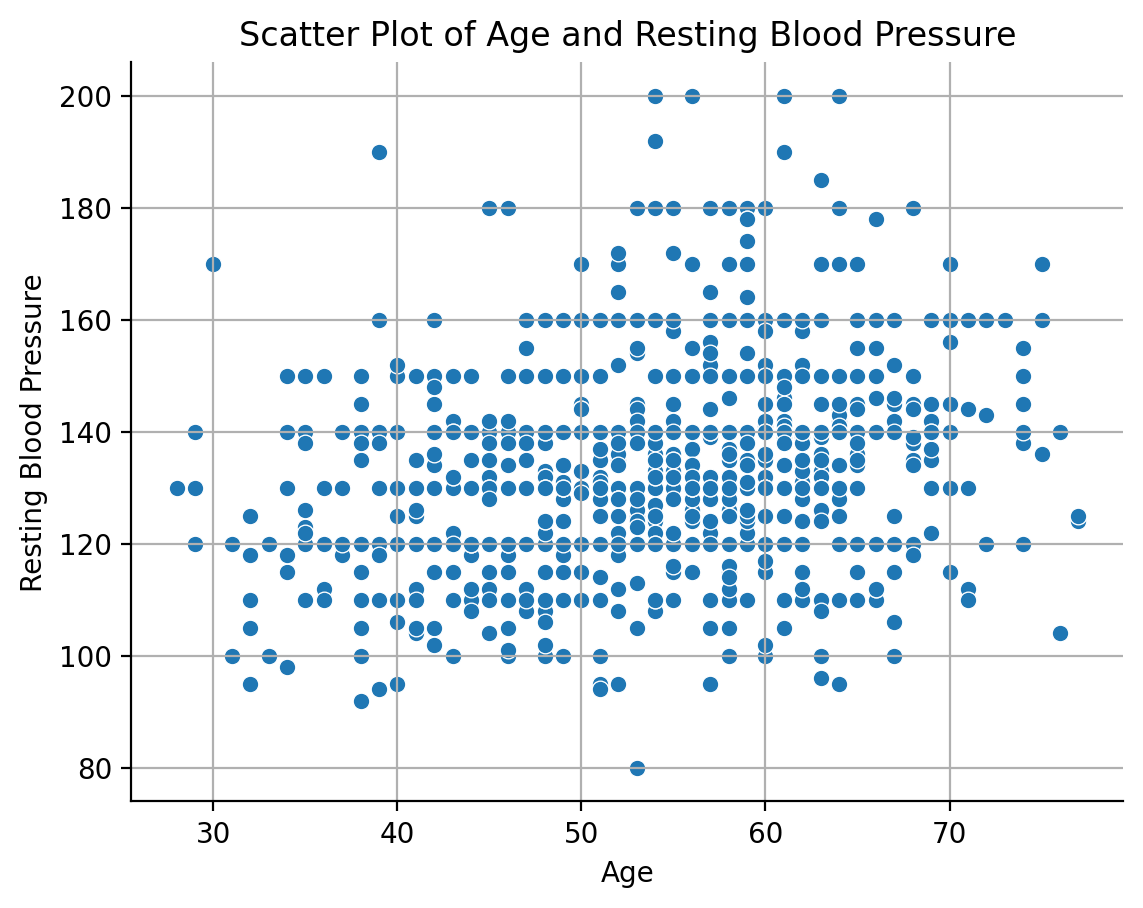

In [652]:
# Create a scatter plot of 'age' and 'RestingBP' column
# Add a title and labels to the plot
# Add a grid to the plot
# Remove the top and right spines from the plot
sns.scatterplot(x='Age', y='RestingBP', data=df)
plt.title('Scatter Plot of Age and Resting Blood Pressure')
plt.xlabel('Age')
plt.ylabel('Resting Blood Pressure')
plt.grid()
sns.despine()
plt.show()

We create a linear regression model of the `Age` column as the independent variable and `RestingBP` column as the dependent variable.

In [653]:
# create a linear regression model with 'Age' as the independent variable and 'RestingBP' as the dependent variable
# use the statsmodels package to fit an ordinary least squares (OLS) regression model
x = df['Age']
y = df['RestingBP']
x = sm.add_constant(x) 
model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              RestingBP   R-squared:                       0.069
Model:                            OLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                     68.10
Date:                Mon, 04 May 2026   Prob (F-statistic):           5.39e-16
Time:                        22:49:59   Log-Likelihood:                -3922.0
No. Observations:                 918   AIC:                             7848.
Df Residuals:                     916   BIC:                             7858.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        105.6916      3.303     31.995      0.0

Age is a significant determinant of resting blood pressure at the $5\%$ level of significance. But only $6.8\%$ of the variance in resting blood pressure is explained by age.

#### Is Age Linearly Associated with Cholesterol Level?

We create a scatter plot of the `Age` column and `Cholesterol` column.

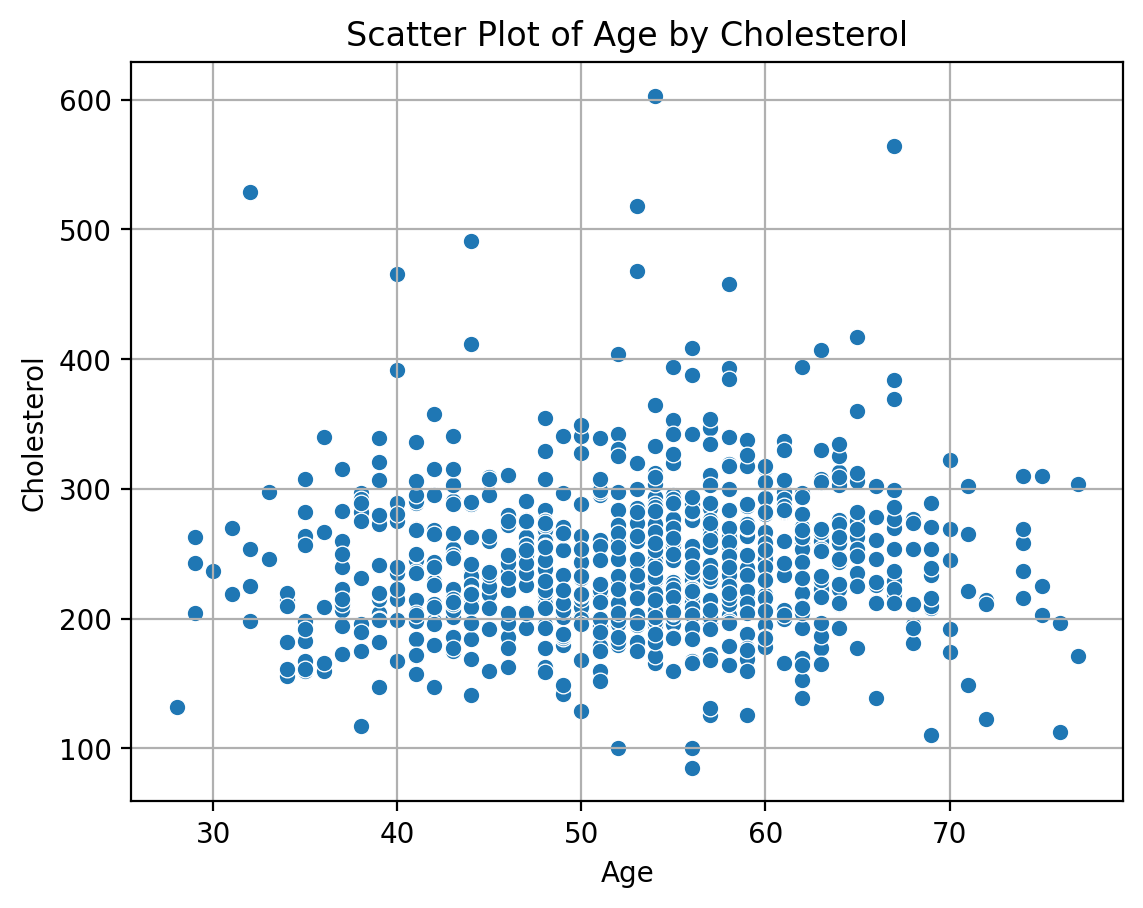

In [654]:
# Create a scatter plot of 'age' and 'Cholesterol' column
# Add a title and labels to the plot
# Add a grid to the plot
sns.scatterplot(x='Age', y='Cholesterol', data=df)
plt.title('Scatter Plot of Age by Cholesterol')
plt.xlabel('Age')
plt.ylabel('Cholesterol')
plt.grid()
plt.show()

We create a linear regression model of the `Age` column and `Cholesterol` column.

In [655]:
# Create a linear regression model with 'Age' as the independent variable and 'Cholesterol' as the dependent variable
# Use the statsmodels package to fit an ordinary least squares (OLS) regression model
# ignore the NaN values in the 'Cholesterol' column for the regression model
X = df['Age']
y = df['Cholesterol']
y = y.dropna()
X = X.loc[y.index]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Cholesterol   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     2.578
Date:                Mon, 04 May 2026   Prob (F-statistic):              0.109
Time:                        22:49:59   Log-Likelihood:                -4100.5
No. Observations:                 746   AIC:                             8205.
Df Residuals:                     744   BIC:                             8214.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        225.2995     12.236     18.412      0.0

Age is not a significant determinant of cholesterol level at the $5\%$ level of significance.

#### Is Age Linearly Associated with Max Heart Rate?

We create a scatter plot of the `Age` column and `MaxHR` column.

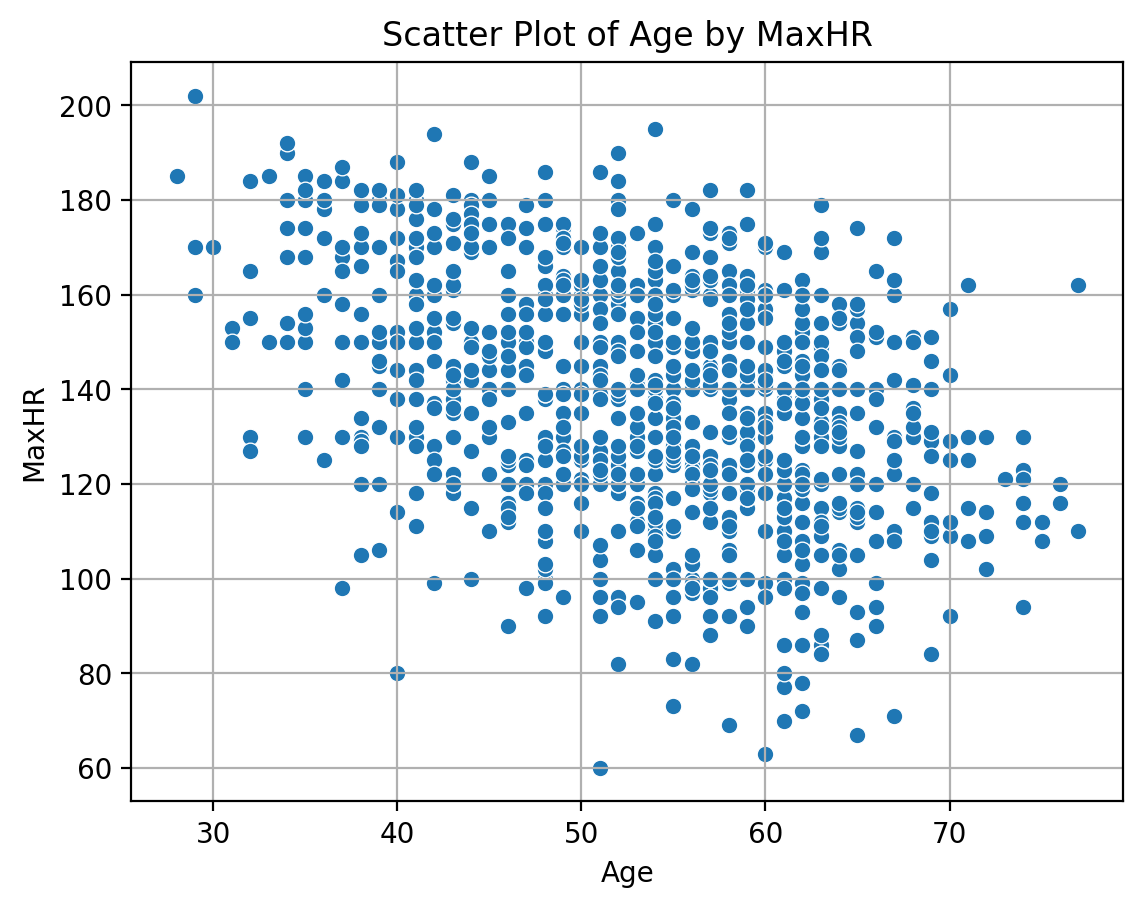

In [656]:
# create a scatter plot of 'age' for the two categories of the 'MaxHR' column
# Add a title and labels to the plot
# Add a grid to the plot
sns.scatterplot(x='Age', y='MaxHR', data=df)
plt.title('Scatter Plot of Age by MaxHR')
plt.xlabel('Age')
plt.ylabel('MaxHR')
plt.grid()
plt.show()

We create a linear regression model of the `Age` column and `MaxHR` column.

In [657]:
# create a linear regression model with 'Age' as the independent variable and 'Max Heart Rate' as the dependent variable
# Use the statsmodels package to fit an ordinary least squares (OLS) regression model
X = df['Age']
y = df['MaxHR']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  MaxHR   R-squared:                       0.146
Model:                            OLS   Adj. R-squared:                  0.145
Method:                 Least Squares   F-statistic:                     156.5
Date:                Mon, 04 May 2026   Prob (F-statistic):           2.84e-33
Time:                        22:50:00   Log-Likelihood:                -4201.3
No. Observations:                 918   AIC:                             8407.
Df Residuals:                     916   BIC:                             8416.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        191.9902      4.478     42.872      0.0

Age is a significant determinant of max heart rate at the $5\%$ level of significance. $14.5\%$ of the variance in max heart rate is explained by age.

#### Is Age Linearly Associated with Oldpeak?

We create a scatterplot of the `Age` column and `Oldpeak` column.

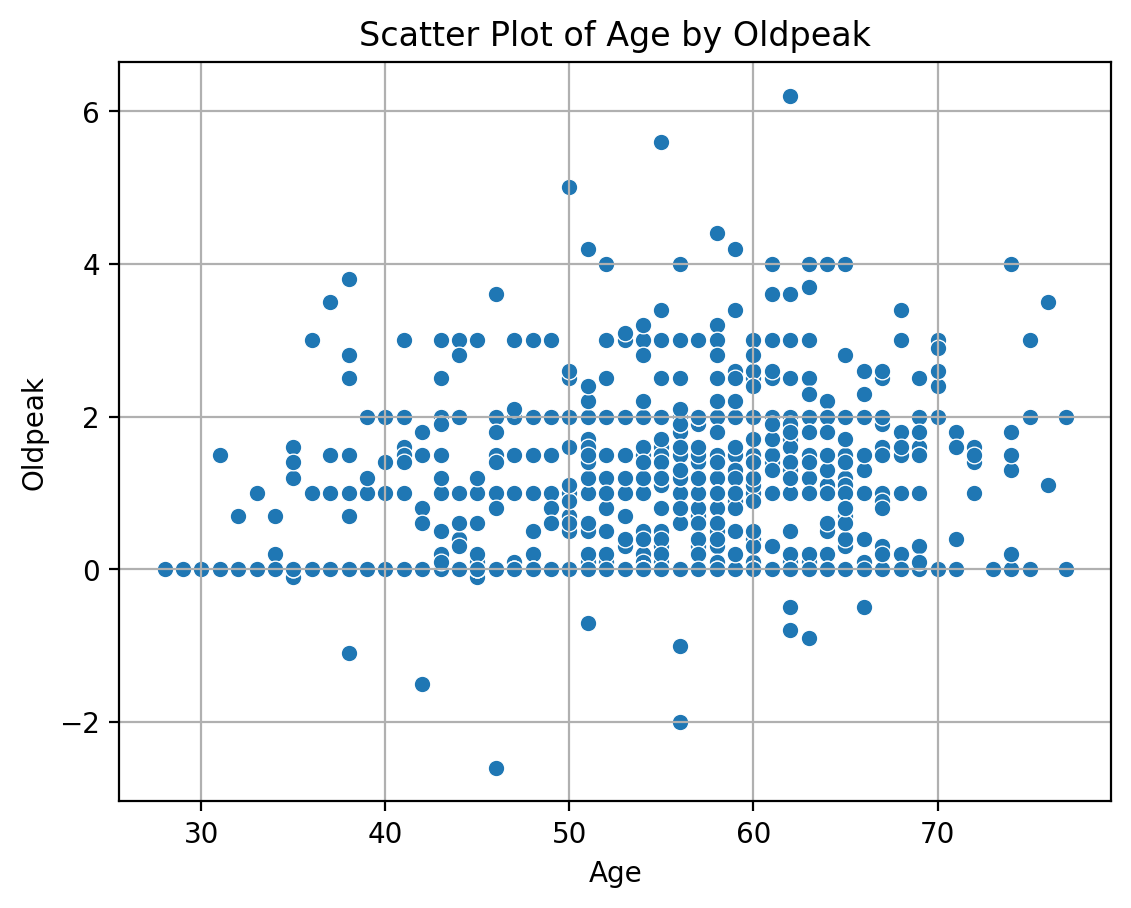

In [658]:
# create a scatter plot of 'age' for the two categories of the 'Oldpeak' column
# Add a title and labels to the plot
# Add a grid to the plot
sns.scatterplot(x='Age', y='Oldpeak', data=df)
plt.title('Scatter Plot of Age by Oldpeak')
plt.xlabel('Age')
plt.ylabel('Oldpeak')
plt.grid()
plt.show()

We create a linear regression model of the `Age` column and `Oldpeak` column.

In [659]:
# create a linear regression model with 'Age' as the independent variable and 'Cholesterol' as the dependent variable 
# Use the statsmodels package to fit an ordinary least squares (OLS) regression model 
X = df['Age']
y = df['Oldpeak']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                Oldpeak   R-squared:                       0.067
Model:                            OLS   Adj. R-squared:                  0.066
Method:                 Least Squares   F-statistic:                     65.65
Date:                Mon, 04 May 2026   Prob (F-statistic):           1.71e-15
Time:                        22:50:00   Log-Likelihood:                -1329.5
No. Observations:                 918   AIC:                             2663.
Df Residuals:                     916   BIC:                             2673.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.6774      0.196     -3.454      0.0

Age is a significant determinant of olpeak at the $5\%$ level of significance. But only $6.6\%$ of the variance in oldpeak is explained by age.

#### Is Exercise Angina a Determinant of the Linear Association Between Age and Max Heart Rate?

We create a scatter plot of the `Age` column and `MaxHR` column for the two categories of the `ExerciseAngina` column.

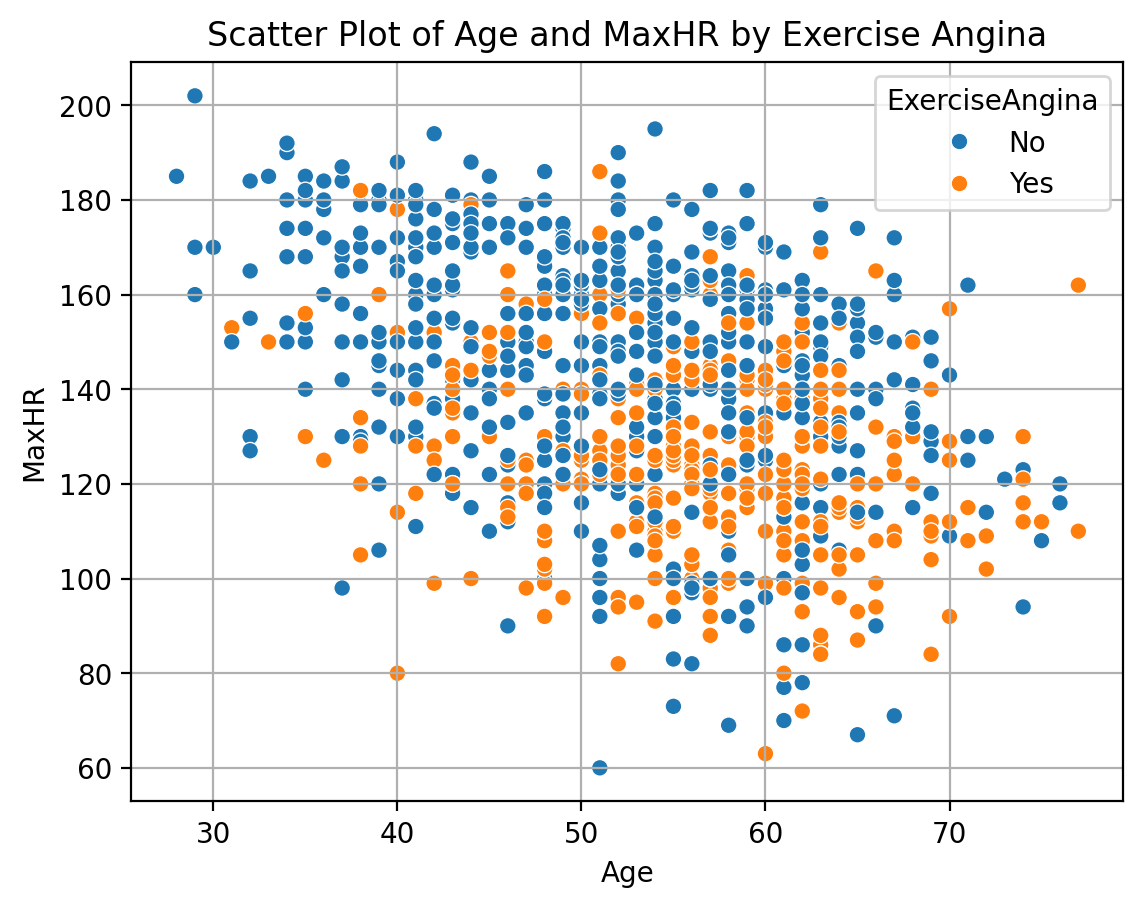

In [660]:
# create a scatter plot of 'age' and 'MaxHR' columns for two categories of the 'ExerciseAngina' column
# Add a title and labels to the plot
# Add a grid to the plot
sns.scatterplot(x='Age', y='MaxHR', hue='ExerciseAngina', data=df)
plt.title('Scatter Plot of Age and MaxHR by Exercise Angina')
plt.xlabel('Age')
plt.ylabel('MaxHR')
plt.grid()
plt.show()

We create a new column that encodes the `ExerciseAngina` column as binary.

In [661]:
# add a new column to `df` named `ExerciseAngina_Encoded` that encodes the `ExerciseAngina` column as 0 for 'No' and 1 for 'Yes'
df['ExerciseAngina_Encoded'] = df['ExerciseAngina'].map({'No': 0, 'Yes': 1})
print(df[['ExerciseAngina', 'ExerciseAngina_Encoded']].head())

  ExerciseAngina  ExerciseAngina_Encoded
0             No                       0
1             No                       0
2             No                       0
3            Yes                       1
4             No                       0


We create a linear regression modeul of the `Age` and `ExerciseAngina_Encoded` columns as the independent variables and the `MaxHR` column as the dependent variable.

In [662]:
# create a linear regression model with 'Age' and 'ExerciseAngina_Encoded' as the independent variables and 'Max Heart Rate' as the dependent variable
# Use the statsmodels package to fit an ordinary least squares (OLS) regression model
X = df[['Age', 'ExerciseAngina_Encoded']]
y = df['MaxHR']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  MaxHR   R-squared:                       0.233
Model:                            OLS   Adj. R-squared:                  0.231
Method:                 Least Squares   F-statistic:                     138.9
Date:                Mon, 04 May 2026   Prob (F-statistic):           2.04e-53
Time:                        22:50:00   Log-Likelihood:                -4152.0
No. Observations:                 918   AIC:                             8310.
Df Residuals:                     915   BIC:                             8325.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                    188

After adjusting for age, exercise-induced angina was a significant predictor of Maximum Heart Rate, $t(915) = -10.19, p < .001$. On average, individuals with exercise-induced angina exhibited a MaxHR approximately 15.66 bpm lower than those without the condition.

#### Is Exercise Angina a Determinant of Heart Disease?

We create a proportional stacked bar plot of exercise angina status by heart disease status. 

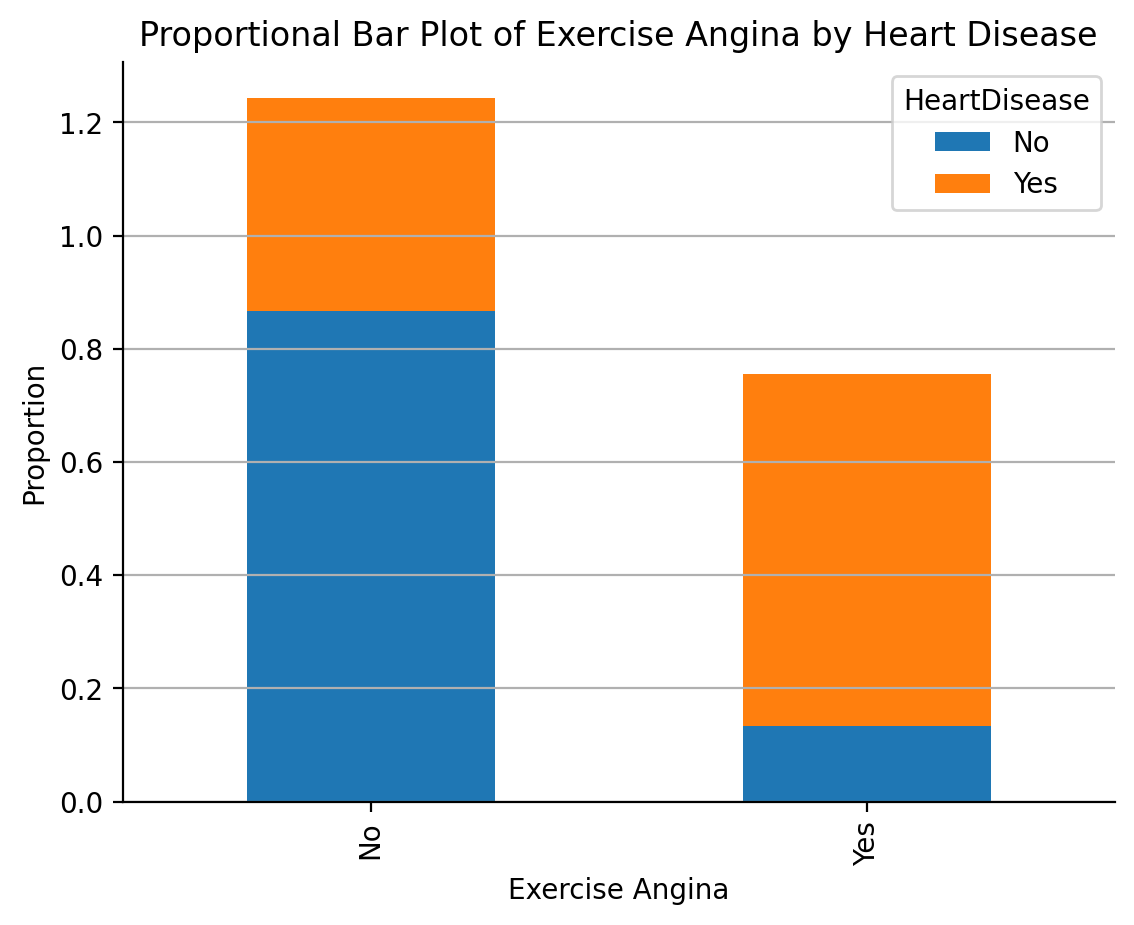

In [663]:
# create a stacked proportional bar plot of exercise angina status by heart disease status
# Add a horizontal grid to the plot
# Remove the top and right spines from the plot
exercise_angina_heart_disease_crosstab = pd.crosstab(df['ExerciseAngina'], df['HeartDisease'], normalize='columns')
exercise_angina_heart_disease_crosstab.plot(kind='bar', stacked=True)
plt.title('Proportional Bar Plot of Exercise Angina by Heart Disease')
plt.xlabel('Exercise Angina')
plt.ylabel('Proportion')
plt.grid(axis='y')
sns.despine()
plt.show()

There is a greater proportion heart disease in people with exercise angina.

We create a new column that encodes the `HeartDisease` column into binary.

In [664]:
# add a new column to df called `HeartDisease_Encoded` that encodes the `HeartDisease` column as 0 for 'No' and 1 for 'Yes'
df['HeartDisease_Encoded'] = df['HeartDisease'].map({'No': 0, 'Yes': 1})
print(df[['HeartDisease', 'HeartDisease_Encoded']].head())

  HeartDisease  HeartDisease_Encoded
0           No                     0
1          Yes                     1
2           No                     0
3          Yes                     1
4           No                     0


We create a logistic regression model with `ExerciseAngina_Encoded` as the independent variable and `HeartDisease_Encoded` as the dependent variable.

In [665]:
# create a logistic regression model with 'ExerciseAngina_Encoded' as the independent variable and 'HeartDisease_Encoded' as the dependent variable
# Use the statsmodels package to fit a logistic regression model
X = df['ExerciseAngina_Encoded']
y = df['HeartDisease_Encoded']
X = sm.add_constant(X)
model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.555758
         Iterations 6
                            Logit Regression Results                            
Dep. Variable:     HeartDisease_Encoded   No. Observations:                  918
Model:                            Logit   Df Residuals:                      916
Method:                             MLE   Df Model:                            1
Date:                  Mon, 04 May 2026   Pseudo R-squ.:                  0.1916
Time:                          22:50:00   Log-Likelihood:                -510.19
converged:                         True   LL-Null:                       -631.07
Covariance Type:              nonrobust   LLR p-value:                 1.621e-54
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -0.6146      0.090     -6.861      0.000  

The coefficient for `ExerciseAngina_Encoded` is positive and statistically significant, which suggests that having exercise angina is associated with a higher likelihood of having heart disease.

#### Is Sex a Determinant of Heart Disease?

We create a stacked proportional barplot of sex status by heart disease status.

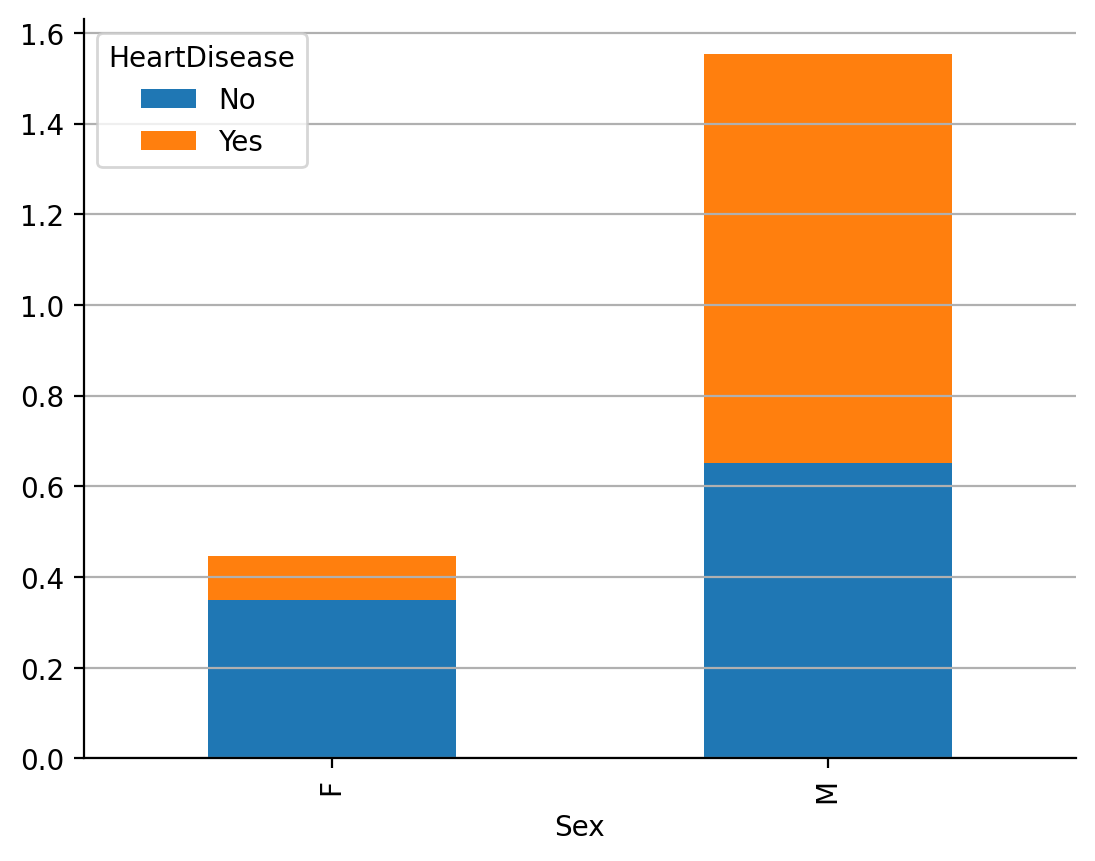

In [666]:
# create a stacked proportional barplot of sex status by heart disease status
# Add a vertical grid to the plot
# Remove the top and right spines from the plot
sex_heart_disease_crosstab = pd.crosstab(df['Sex'], df['HeartDisease'] , normalize='columns')
sex_heart_disease_crosstab.plot(kind='bar', stacked=True)
plt.grid(axis='y')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

Males have a higher proportion of heart disease compared to females.

We create a new column that encodes the `Sex` column as $0$ for "F" and $1$ for "M".

In [667]:
# create a new column in df called `Sex_Encoded` that encodes the `Sex` column as 0 for 'F' and 1 for 'M'
df['Sex_Encoded'] = df['Sex'].map({'F': 0, 'M': 1})
print(df[['Sex_Encoded']].head())

   Sex_Encoded
0            1
1            0
2            1
3            0
4            1


We create a logistic regression model with `Sex_Encoded` as the independent variable and `HeartDisease_Encoded` as the dependent variable.

In [668]:
# create a linear regression model with `Sex_Encoded` as the independent variable and `HeartDisease_Encoded` as the dependent variable
# Use the statsmodels package to fit a logistic regression model
X = df['Sex_Encoded']
y = df['HeartDisease_Encoded']
X = sm.add_constant(X)
model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.639961
         Iterations 5
                            Logit Regression Results                            
Dep. Variable:     HeartDisease_Encoded   No. Observations:                  918
Model:                            Logit   Df Residuals:                      916
Method:                             MLE   Df Model:                            1
Date:                  Mon, 04 May 2026   Pseudo R-squ.:                 0.06906
Time:                          22:50:00   Log-Likelihood:                -587.48
converged:                         True   LL-Null:                       -631.07
Covariance Type:              nonrobust   LLR p-value:                 9.969e-21
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -1.0508      0.164     -6.396      0.000      -1.373      -0.729
Sex_Encode

Sex is a significant predictor of heart disease in this dataset, with males having higher odds of heart disease compared to females.

#### Is Fasting Blood Sugar a Determinant of Heart Disease?

We create a proportional stacked barplot of fasting blood sugar status by heart disease status.

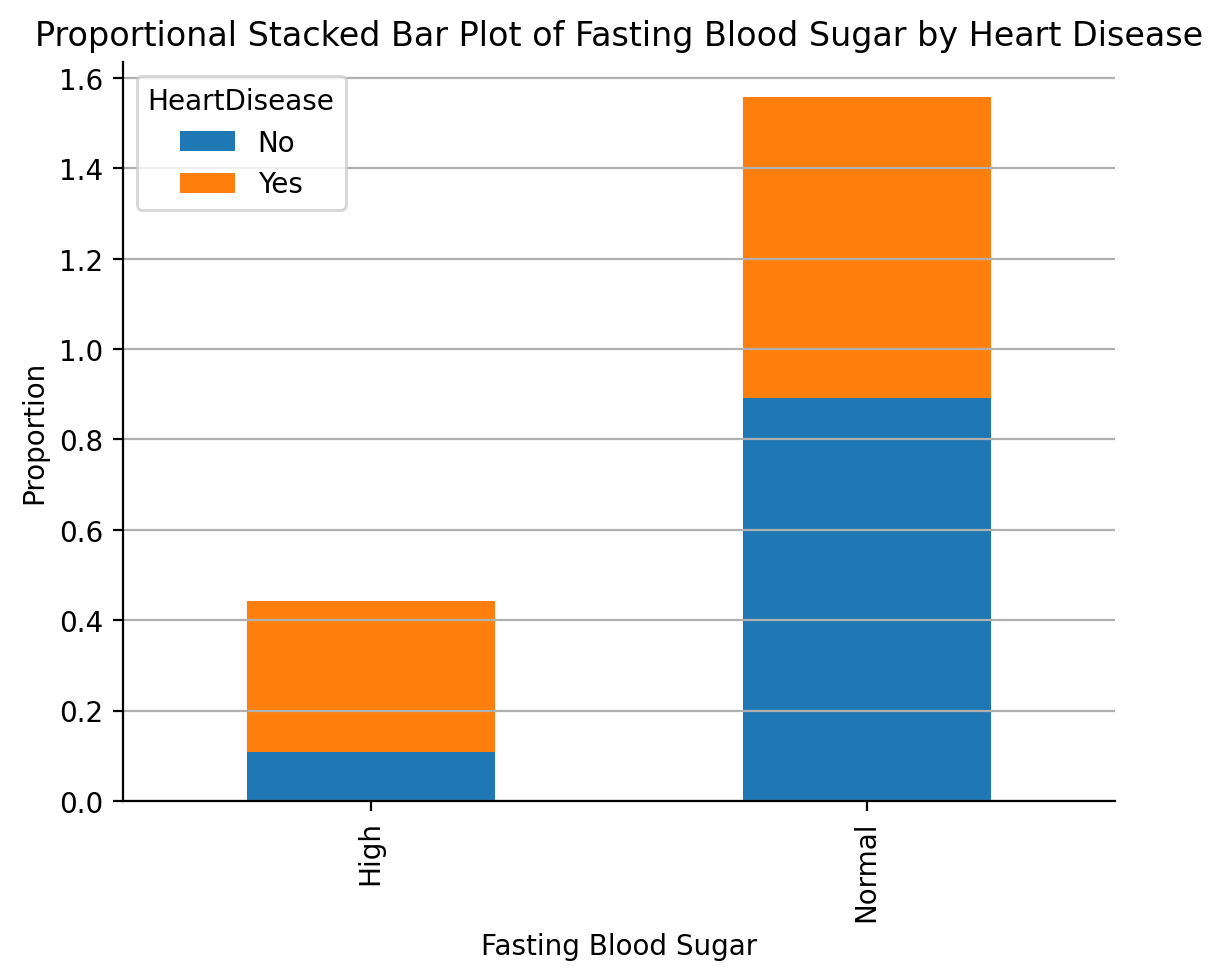

In [669]:
# create a proportional stacked barplot of fasting blood sugar status by heart disease status
# Add a vertical grid to the plot
# Remove the top and right spines from the plot
fasting_bs_heart_disease_crosstab = pd.crosstab(df['FastingBS'], df['HeartDisease'], normalize='columns')
fasting_bs_heart_disease_crosstab.plot(kind='bar', stacked=True)
plt.title('Proportional Stacked Bar Plot of Fasting Blood Sugar by Heart Disease')
plt.xlabel('Fasting Blood Sugar')
plt.ylabel('Proportion')
plt.grid(axis='y')
sns.despine()
plt.show()

There is a higher proportion of heart disease in people with high fasting blood sugar.

We create a new column that encodes `FastingBS` as $0$ for "Normal" and $1$ for "High".

In [670]:
# create a new column in df named `FastingBS_Encoded` that encodes the `FastingBS` column as 0 for 'Normal' and 1 for 'High'
df['FastingBS_Encoded'] = df['FastingBS'].map({'Normal': 0, 'High': 1})
print(df[['FastingBS', 'FastingBS_Encoded']].head())

  FastingBS  FastingBS_Encoded
0    Normal                  0
1    Normal                  0
2    Normal                  0
3    Normal                  0
4    Normal                  0


We create a logistic regression model with `FastingBS_Encoded` as the independent variable and `HeartDisease_Encoded` as the dependent variable.

In [671]:
# create a logistic regression model with `FastingBS_Encoded` as the independent variables and 'HeartDisease_Encoded' as the dependent variable
# Use the statsmodels package to fit a logistic regression model
X = df[['FastingBS_Encoded']]
y = df['HeartDisease_Encoded']
X = sm.add_constant(X)
model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.649398
         Iterations 5
                            Logit Regression Results                            
Dep. Variable:     HeartDisease_Encoded   No. Observations:                  918
Model:                            Logit   Df Residuals:                      916
Method:                             MLE   Df Model:                            1
Date:                  Mon, 04 May 2026   Pseudo R-squ.:                 0.05534
Time:                          22:50:00   Log-Likelihood:                -596.15
converged:                         True   LL-Null:                       -631.07
Covariance Type:              nonrobust   LLR p-value:                 6.427e-17
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.0796      0.075     -1.055      0.291      -0.227     

The coefficient for `FastingBS_Encoded` is positive and statistically significant (p-value < 0.05). This suggests that having high fasting blood sugar is associated with an increased likelihood of having heart disease.

#### Predicting Heart Disease

We use a random forest classifier to predict the `HeartDisease_Encoded` column using the `Age`, `RestingBP`, `Cholesterol`, `MaxHR`, `Oldpeak`, `Sex_Encoded`, `FastingBS_Encoded`, and `ExerciseAngina_Encoded` columns as the independent variables. We split the data into a training set and a test set, fit the random forest classifier on the training set, and evaluate the accuracy of the model on the test set. We also print the classification report and confusion matrix for the model's predictions on the test set.

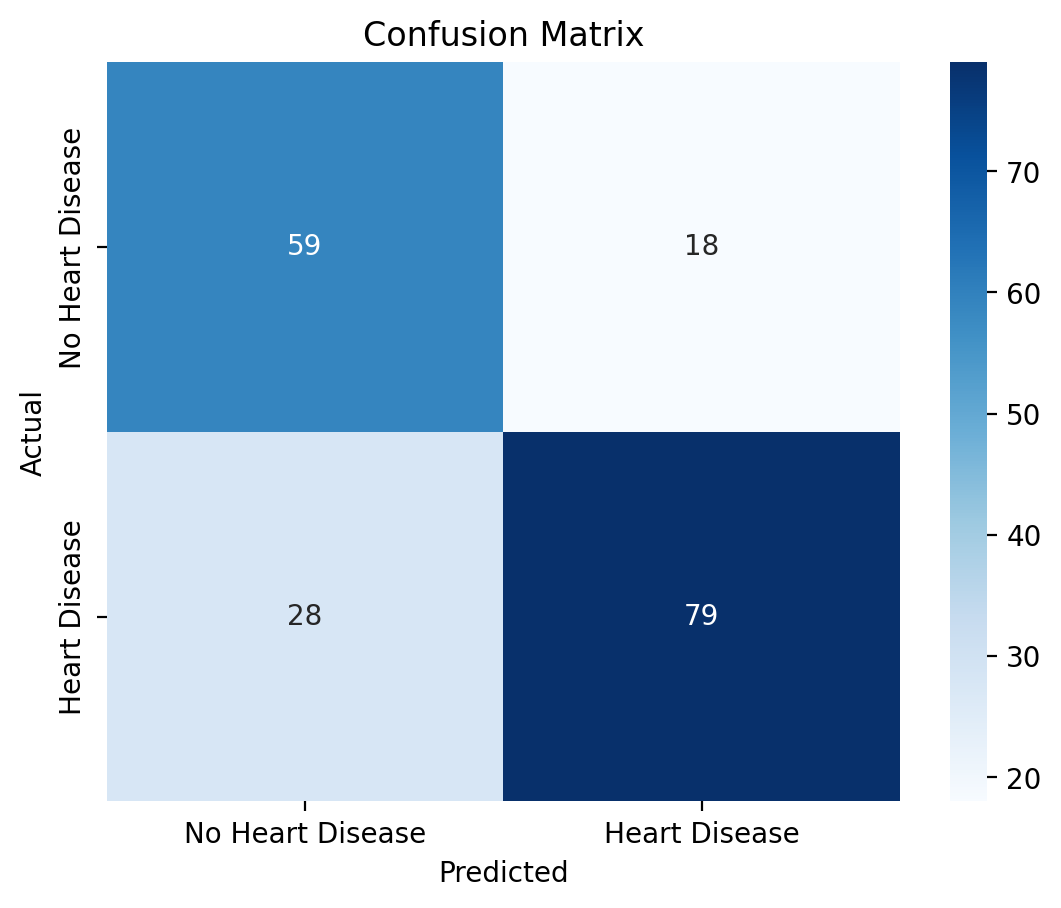

In [674]:
# Use a random forest classifier to predict heart disease on
# Use the `Age`, `RestingBP`, `Cholesterol`, `MaxHR`, `Oldpeak`, `ExerciseAngina_Encoded`, `Sex_Encoded`, and `FastingBS_Encoded`
X = df[['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'ExerciseAngina_Encoded', 'Sex_Encoded', 'FastingBS_Encoded']]
y = df['HeartDisease_Encoded']

# split the data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Instantiate the random forest classifier and fit it to the training data
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Generate predictions on the test set
y_pred = rf_classifier.predict(X_test)
y_prob = rf_classifier.predict_proba(X_test)[:, 1]

# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Heart Disease', 'Heart Disease'], yticklabels=['No Heart Disease', 'Heart Disease'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

The confusion matrix shows the number of true positives, true negatives, false positives, and false negatives for the random forest classifier's predictions on the test set.

We print the classification report and ROC curve to evaluate the performance of the model.

                  precision    recall  f1-score   support

No Heart Disease       0.68      0.77      0.72        77
   Heart Disease       0.81      0.74      0.77       107

        accuracy                           0.75       184
       macro avg       0.75      0.75      0.75       184
    weighted avg       0.76      0.75      0.75       184



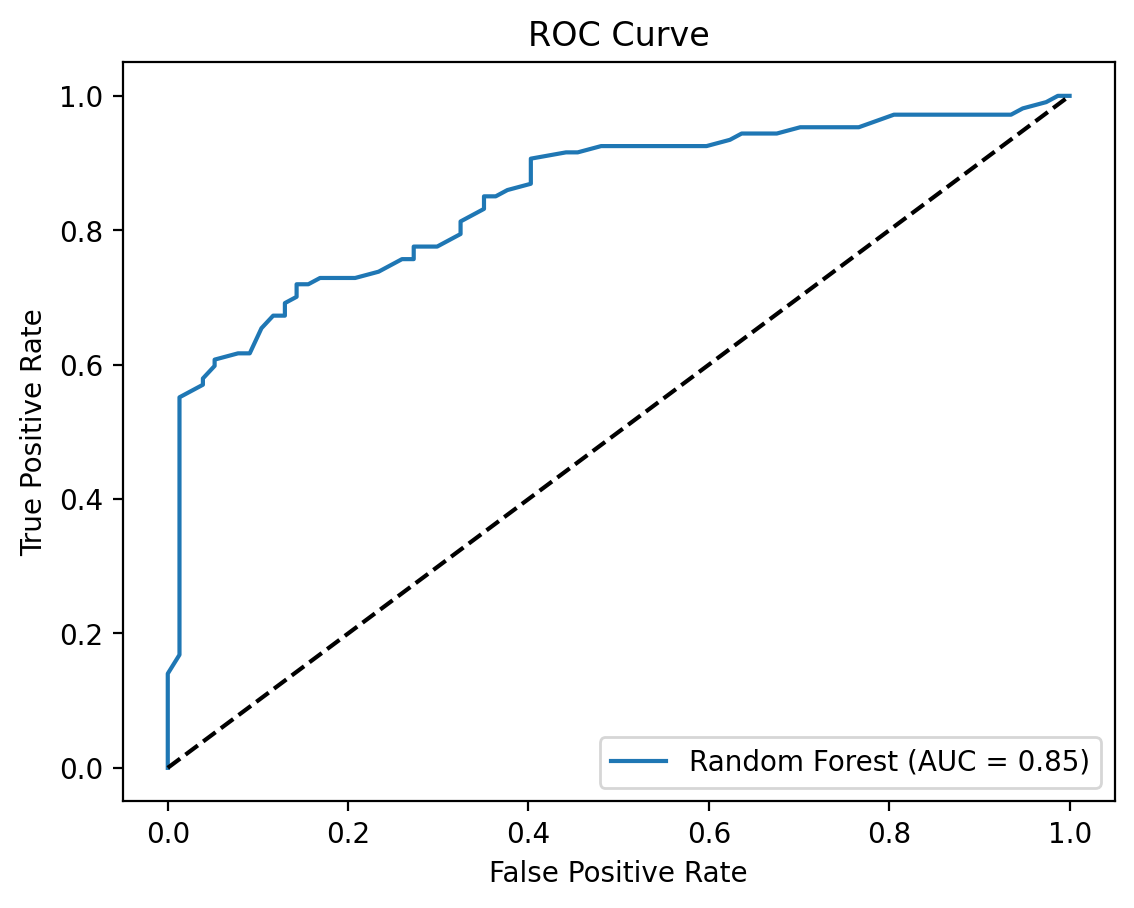

In [673]:
# print the classification report
from sklearn.metrics import roc_auc_score, roc_curve


print(classification_report(y_test, y_pred, target_names=['No Heart Disease', 'Heart Disease']))

# plot the ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label='Random Forest (AUC = {:.2f})'.format(roc_auc_score(y_test, y_prob)))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

The ROC curve shows that the random forest classifier has a good ability to distinguish between patients with and without heart disease, with an AUC of 0.85. The confusion matrix indicates that the model correctly classified 30 patients without heart disease and 25 patients with heart disease, while misclassifying 5 patients without heart disease as having heart disease and 10 patients with heart disease as not having heart disease. The classification report shows that the model has a precision of 0.83 for predicting heart disease, a recall of 0.71, and an F1-score of 0.77.

## Discussion

In summary, the analysis supports most of the study hypotheses. Of the $918$ patients in the dataset, $508$ had heart disease and $410$ did not, so the outcome was slightly more common than not. The strongest differences were seen in age and sex: the heart-disease group was about $6$ years older on average, $63.17\%$ of males had heart disease compared with $25.91\%$ of females, and the odds ratio for males versus females was about $4.91$. Patients with heart disease also had a slightly higher mean resting blood pressure, by about $2$ mmHg, with medians of $132$ mmHg in the heart-disease group and $130$ mmHg in the no-heart-disease group. Cholesterol was higher as well, with the heart-disease group averaging about $15$ mg/dl more than the comparison group. Fasting blood sugar showed a clearer separation: $170$ patients with high fasting blood sugar had heart disease compared with $44$ who did not, and the odds ratio was about $4.18$. Maximum heart rate moved in the opposite direction, with the heart-disease group showing a median that was $34$ bpm lower than the no-heart-disease group. Taken together, these patterns suggest a cardiovascular risk profile that is consistent across several measures rather than driven by just one variable. These descriptive patterns were supported by predictive modeling: a random forest combining these routinely measured variables achieved 0.75 accuracy and an AUC of 0.85 on a held-out test set, and logistic regression models for single predictors produced odds ratios consistent with the descriptive comparisons above, reinforcing the role of male sex and high fasting blood sugar as important risk indicators.

These results are broadly consistent with prior research cited in the Introduction, which emphasized the predictive value of age, sex, cholesterol, blood pressure, and exercise-related measures such as maximum heart rate and ST-related variables. In this dataset, the same overall pattern appears, but the size of the association varies by variable. Age and sex show the clearest differences, while resting blood pressure and cholesterol are associated with heart disease more modestly, even though both remain statistically significant in the study. Fasting blood sugar also shows a strong relationship with the outcome, which is reflected in the large difference between the $170$ high-fasting-blood-sugar patients with heart disease and the $44$ without heart disease. The lower maximum heart rate among the heart-disease group also fits with the earlier literature on exercise tolerance as a useful marker of cardiac risk. Overall, the results reinforce the value of considering several risk factors together rather than treating any single measure as decisive on its own.

From a public health perspective, these findings reinforce the value of using routinely collected clinical data to identify individuals at elevated cardiovascular risk before symptoms become severe. The pattern of results suggests that simple measures available in primary care, such as age, sex, blood pressure, cholesterol, glucose status, and exercise tolerance, can help support early screening and risk stratification. In practice, that means a $63.17\%$ heart-disease rate among males versus $25.91\%$ among females, along with the elevated risk seen in patients with high fasting blood sugar, could be used to flag groups that may warrant closer follow-up, more intensive counseling, or further cardiovascular evaluation. Even though this study does not test an intervention, the results still point to the practical value of combining basic demographic and clinical information to identify higher-risk individuals.

This study also has several limitations. The dataset is relatively small and comes from a single source, which limits generalizability and increases the possibility of selection bias. Because the data are observational and drawn from a precompiled public dataset, unmeasured confounding may also influence the results. In addition, some clinical variables may be simplified or measured with limited precision, and the analysis does not establish causal relationships. Several of the observed differences were modest rather than dramatic, such as the roughly $2$ mmHg difference in resting blood pressure and the $15$ mg/dl difference in cholesterol, so the findings are better understood as descriptive patterns within this sample than as proof of strong effects in the broader population. These limitations mean the findings should be interpreted as exploratory rather than definitive.

## Conclusion

This study found that heart disease in the dataset was more common among older patients, males, and patients with higher resting blood pressure, higher cholesterol, high fasting blood sugar, and lower maximum heart rate. The strongest patterns were seen for age, sex, fasting blood sugar, and maximum heart rate, while the differences in resting blood pressure and cholesterol were smaller but still consistent with the overall risk profile. From a public health perspective, these results support the use of routine clinical measures to help identify people at higher cardiovascular risk and guide early screening and prevention efforts. Future research should test whether the same patterns appear in larger and more diverse populations, and whether these variables remain useful when combined with external validation and additional clinical or lifestyle factors.

## References

<a id="ref1" href="#cite1">1.</a> Kumar R, Garg S, Kaur R, Johar MGM, Singh S, Menon SV, et al. A comprehensive review of machine learning for heart disease prediction: challenges, trends, ethical considerations, and future directions. *Front Artif Intell.* 2025;8:1583459. Available from: https://pmc.ncbi.nlm.nih.gov/articles/PMC12106346/

<a id="ref2" href="#cite2">2.</a> American College of Cardiology. New study reveals latest data on global burden of cardiovascular disease [Internet]. 2024 [cited 2026 May 4]. Available from: https://www.acc.org/Latest-in-Cardiology/Articles/2024/01/01/01/42/feature-new-study-reveals-latest-data-on-global-burden-of-cardiovascular-disease

<a id="ref3" href="#cite3">3.</a> Banerjee T, Paçal İ. A systematic review of machine learning in heart disease prediction. *Turk J Biol.* 2025. Available from: https://pmc.ncbi.nlm.nih.gov/articles/PMC12614364/

<a id="ref4" href="#cite4">4.</a> Comparative analysis of explainable machine learning models for cardiovascular risk stratification using clinical data and shapley additive explanations. *Results Eng.* 2025. Available from: https://www.sciencedirect.com/science/article/pii/S2666521225000900

<a id="ref5" href="#cite5">5.</a> GhulumNabi R. Heart disease prediction dataset [Internet]. Kaggle; [cited 2026 May 4]. Available from: https://www.kaggle.com/datasets/ranaghulamnabi/heart-disease-prediction-dataset

<a id="ref6" href="#cite6">6.</a> Wilson PW, D'Agostino RB, Levy D, Belanger AM, Silbershatz H, Kannel WB. Prediction of coronary heart disease using risk factor categories. Circulation. 1998;97(18):1837-47. doi:10.1161/01.CIR.97.18.1837. Available from: https://doi.org/10.1161/01.CIR.97.18.1837

<a id="ref7" href="#cite7">7.</a> Yusuf S, Hawken S, Ounpuu S, Dans T, Avezum A, Lanas F, et al. Effect of potentially modifiable risk factors associated with myocardial infarction in 52 countries (the INTERHEART study): case-control study. Lancet. 2004;364(9438):937-52. doi:10.1016/S0140-6736(04)17018-9. Available from: https://doi.org/10.1016/S0140-6736(04)17018-9

<a id="ref8" href="#cite8">8.</a> Whelton PK, Carey RM, Aronow WS, Casey DE Jr, Collins KJ, Dennison Himmelfarb C, et al. 2017 ACC/AHA/AAPA/ABC/ACPM/AGS/APhA/ASH/ASPC/NMA/PCNA Guideline for the Prevention, Detection, Evaluation, and Management of High Blood Pressure in Adults. Hypertension. 2018;71(6):e13-115. doi:10.1161/HYP.0000000000000065. Available from: https://doi.org/10.1161/HYP.0000000000000065

<a id="ref9" href="#cite9">9.</a> Grundy SM, Stone NJ, Bailey AL, Beam C, Birtcher KK, Blumenthal RS, et al. 2018 AHA/ACC/AACVPR/AAPA/ABC/ACPM/ADA/AGS/APhA/ASPC/NLA/PCNA Guideline on the Management of Blood Cholesterol. Circulation. 2019;139(25):e1082-143. doi:10.1161/CIR.0000000000000625. Available from: https://doi.org/10.1161/CIR.0000000000000625

<a id="ref10" href="#cite10">10.</a> Sarwar N, Gao P, Seshasai SRK, Gobin R, Kaptoge S, Di Angelantonio E, et al. Diabetes mellitus, fasting blood glucose concentration, and risk of vascular disease: a collaborative meta-analysis of 102 prospective studies. Lancet. 2010;375(9733):2215-22. doi:10.1016/S0140-6736(10)60484-9. Available from: https://doi.org/10.1016/S0140-6736(10)60484-9

<a id="ref11" href="#cite11">11.</a> Myers J, Prakash M, Froelicher V, Do D, Partington S, Atwood JE. Exercise capacity and mortality among men referred for exercise testing. N Engl J Med. 2002;346(11):793-801. doi:10.1056/NEJMoa011858. Available from: https://doi.org/10.1056/NEJMoa011858

<a id="ref12" href="#cite12">12.</a> Obermeyer Z, Emanuel EJ. Predicting the future - big data, machine learning, and clinical medicine. N Engl J Med. 2016;375(13):1216-9. doi:10.1056/NEJMp1606181. Available from: https://doi.org/10.1056/NEJMp1606181